In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.mplot3d import Axes3D
import random
import itertools
import math

ROOM_SIZE = 5  #Odd
DEGREE = 4
EPISODES = 20000
STEP_SIZE_0 = 5*(10**-2)
STEP_SIZE_1 = 1*(10**-5)
DISCOUNT = .9
SHOW_EPISODE = 250
SIZE = ROOM_SIZE*2+1
NUM_TEST = 30

def main():
    epsilon = 1
    step_size = STEP_SIZE_0
    weights = np.full((DEGREE+1,)*6, 0.0)
    train_avg,test_avg = [],[]

    for current in range(EPISODES):
        x1 = [[np.random.randint([0,ROOM_SIZE+1,0,ROOM_SIZE+1][i],[ROOM_SIZE,SIZE,ROOM_SIZE,SIZE][i]) for _ in range(ROOM_SIZE)] for i in range(4)]
        y1 = [[np.random.randint([0,0,ROOM_SIZE+1,ROOM_SIZE+1][i],[ROOM_SIZE,ROOM_SIZE,SIZE,SIZE][i]) for _ in range(ROOM_SIZE)] for i in range(4)]
        pos_combined = [(a, b) for c1, c2 in zip(x1, y1) for a, b in zip(c1, c2)]
        g1 = [[np.random.randint([ROOM_SIZE+1,ROOM_SIZE+1,ROOM_SIZE+1,ROOM_SIZE+1][i],[SIZE,SIZE,SIZE,SIZE][i]) for _ in range(ROOM_SIZE)] for i in range(4)]
        g2 = [[np.random.randint([ROOM_SIZE+1,ROOM_SIZE+1,ROOM_SIZE+1,ROOM_SIZE+1][i],[SIZE,SIZE,SIZE,SIZE][i]) for _ in range(ROOM_SIZE)] for i in range(4)]
        goal_combined = [(a, b) for c1, c2 in zip(g1, g2) for a, b in zip(c1, c2)]

        pos_goal = list(zip(pos_combined,goal_combined))
        for pos,goal in pos_goal:
            dist = np.subtract(goal,pos)

            a = pick_action(pos,goal,epsilon,weights)
            action = (round(math.cos(a)),round(math.sin(a)))
            new_pos = find_new(action,pos)
            new_dist = np.subtract(goal,new_pos)

            features = calc_features(pos,goal,dist)
            next_features = calc_features(new_pos,goal,new_dist)
            reward = find_reward(pos,new_pos,goal)

            old_value = np.sum(np.multiply(weights,features))
            new_value = np.sum(np.multiply(weights,next_features))

            td_error = step_size*(reward+DISCOUNT*new_value-old_value)*features
            weights = np.add(weights,td_error)

        if((current+1)%SHOW_EPISODE==0):
            train_avg = calc_average(epsilon,weights,train_avg,current,test=False)
            test_avg = calc_average(epsilon,weights,test_avg,current)

        epsilon = epsilon - epsilon/(EPISODES//2-1)
        step_size = STEP_SIZE_0/(1+((STEP_SIZE_0-STEP_SIZE_1)/(STEP_SIZE_1*EPISODES))*current)


def calc_average(epsilon,weights,store_avg,current,test=True):
    pos_0 = (0,0)
    dist = (0,0)
    count,average = 0,0

    for i in range(NUM_TEST):
        pos,goal = (0,0),(0,0)
        if(test):
            pos = (np.random.randint(ROOM_SIZE+1,SIZE),np.random.randint(0,ROOM_SIZE))
            goal = (np.random.randint(0,ROOM_SIZE),np.random.randint(ROOM_SIZE+1,SIZE))
        else:
            pos = (np.random.randint(0,ROOM_SIZE),np.random.randint(0,ROOM_SIZE))
            goal = (np.random.randint(ROOM_SIZE+1,SIZE),np.random.randint(ROOM_SIZE+1,SIZE))
        pos_0 = pos
        dist = np.subtract(goal,pos)
        while((dist[0]!=0)and(dist[1]!=0)):
            a = pick_action(pos,goal,epsilon,weights)
            action = (round(math.cos(a)),round(math.sin(a)))
            new_pos = find_new(action,pos)
            new_dist = np.subtract(goal,new_pos)
            pos = new_pos
            dist = new_dist
            count += 1
        average = (average*i+count)/((i+1))
        count = 0
    store_avg.append(average)
    if(test):
        show_current(weights,goal,current,average,store_avg,pos_0)
    else:
        show_current(weights,goal,current,average,store_avg,pos_0,test=False)
    return store_avg

def show_current(weights,goal,current,average,store_avg,pos_0,test=True):
    MSE = find_MSE(test,weights)
    print(('DG Test on Episode: 'if test else 'Train Policy Episode: ')+str(current+1)+'\nAverage: '+str(average)+'\nGoal: '+str(goal)+'\nMean Square Error = '+str(MSE),end='\n\n')
    x,y = np.meshgrid(np.arange(SIZE),np.arange(SIZE))
    z1 = np.array([[find_value((i, j), goal, np.subtract(goal, (i, j)), weights) for j in range(SIZE)] for i in range(SIZE)])
    fig = plt.figure(figsize=(18,3.5))
    gs = GridSpec(1, 3, width_ratios=[2,1,2])
    ax1 = fig.add_subplot(gs[0], projection="3d")
    ax1.plot_surface(x,y,z1)
    ax1.set(title='Value Function',xlabel='X',ylabel='Y')
    ax1.view_init(elev=30, azim=-60)
    ax2 = fig.add_subplot(gs[1])
    ax2.plot(SHOW_EPISODE*np.arange(len(store_avg)),np.array(store_avg),color='red')
    ax2.set(title='Policy Test',ylim=[0,1.2*max(store_avg)])
    #plt.xlim([0,EPISODES//SHOW_EPISODE])
    ax3 = fig.add_subplot(gs[2],projection='3d')
    z2 = np.array([[(find_value((i,j),goal,np.subtract(goal,(i,j)),weights)-optimal_value((i, j), goal, test=test))**2 for j in range(SIZE)] for i in range(SIZE)])
    #z2 = np.array([[optimal_value((i, j), goal) for j in range(SIZE)] for i in range(SIZE)])
    ax3.set(title='Error Function',xlabel='X',ylabel='Y')
    ax3.view_init(elev=30, azim=-60)
    ax3.plot_surface(x,y,z2)
    plt.subplots_adjust(wspace=-.1)
    plt.show()
    print_policy(weights,goal,pos_0)
    print('_'*101 if test else '=---'*25 +'=',end='\n')

def find_MSE(test,weights):
    posx,posy = np.indices((SIZE-1,SIZE-1))
    posx = [[posx[i][j] if posx[i][j]<ROOM_SIZE else posx[i][j]+1 for j in range(len(posx[i]))] for i in range(len(posx))]
    posy = [[posy[i][j] if posy[i][j]<ROOM_SIZE else posy[i][j]+1 for j in range(len(posy[i]))] for i in range(len(posy))]
    posx,posy = list(np.ndarray.flatten(np.array(posx))),list(np.ndarray.flatten(np.array(posy)))
    posx.extend([ROOM_SIZE,SIZE-(ROOM_SIZE-1)/2-1,ROOM_SIZE,(ROOM_SIZE-1)/2])
    posy.extend([(ROOM_SIZE-1)/2,ROOM_SIZE,SIZE-(ROOM_SIZE-1)/2-1,ROOM_SIZE])
    goalx,goaly = np.indices((ROOM_SIZE,ROOM_SIZE))
    goaly = goaly + ROOM_SIZE+1
    if(not test):
        goalx = goalx + ROOM_SIZE+1
    goalx,goaly = list(np.ndarray.flatten(np.array(goalx))),list(np.ndarray.flatten(np.array(goaly)))
    all_states = np.array([[(posx[i],posy[i],goalx[j],goaly[j],goalx[j]-posx[i],goaly[j]-posy[i]) for i in range(len(posx))] for j in range(len(goalx))],dtype=object)
    all_states = list(all_states.reshape(int(np.prod(all_states.shape)/6),6))
    all_states = random.sample(all_states,int(len(all_states)/SIZE))
    return sum([(find_value((all_states[i][0],all_states[i][1]),(all_states[i][2],all_states[i][3]),(all_states[i][4],all_states[i][5]),weights)- \
                optimal_value((all_states[i][0],all_states[i][1]),(all_states[i][2],all_states[i][3]),test=test))**2 for i in range(len(all_states))])/len(all_states)

def calc_features(pos,goal,dist):
    indices = np.indices((DEGREE+1,)*6)
    start_x, start_y, end_x, end_y, x_dist, y_dist = [indices[i].flatten() for i in range(6)]
    temp = (
        ((pos[0]/SIZE)**start_x)*((pos[1]/SIZE)**start_y)*
        ((goal[0]/SIZE)**end_x)*((goal[1]/SIZE)**end_y)*
        ((dist[0]/SIZE)**x_dist)*((dist[1]/SIZE)**y_dist)
    )
    temp = temp.reshape((DEGREE+1,)*6)
    return(temp)

def pick_action(pos,goal,epsilon,weights):
    if(np.random.random()<epsilon):
        return(np.random.choice([0,np.pi/2,np.pi,3*np.pi/2]))
    else:
        return((np.pi/2)*arg_max(pos,goal,weights))

def arg_max(pos,goal,weights):
    values = np.zeros(4)
    for i in range(4):
        new_pos = find_new((round(math.cos(np.pi/2*i)),round(math.sin(np.pi/2*i))),pos)
        if(new_pos[0]!=pos[0]or new_pos[1]!=pos[1]):
            values[i] = find_value(new_pos,goal,np.subtract(goal,new_pos),weights)
        else:
            values[i] = -math.inf
    return(np.argmax(values))

def find_value(pos,goal,dist,weights):
    flat_w = weights.flatten()
    indices = np.indices((DEGREE+1,)*6)
    start_x, start_y, end_x, end_y, x_dist, y_dist = [indices[i].flatten() for i in range(6)]
    values = flat_w*(
        ((pos[0]/SIZE)**start_x)*((pos[1]/SIZE)**start_y)*
        ((goal[0]/SIZE)**end_x)*((goal[1]/SIZE)**end_y)*
        ((dist[0]/SIZE)**x_dist)*((dist[1]/SIZE)**y_dist)
    )
    return values.sum()

def min_dist(pos,goal,index=-1):
    if(index==-1):
        return min(np.sum([abs(np.subtract(pos,goal)[i]) for i in [0,1]]),np.sum([abs(np.subtract(pos,(goal[1],goal[0]))[i]) for i in [0,1]]))
    return [np.sum([abs(np.subtract(pos,((ROOM_SIZE-1)/2,ROOM_SIZE-1))[i]) for i in [0,1]]) + np.sum([abs(np.subtract(goal,(SIZE-ROOM_SIZE,SIZE-1-(ROOM_SIZE-1)/2))[i]) for i in [0,1]]), \
            np.sum([abs(np.subtract(pos,(ROOM_SIZE-1,(ROOM_SIZE-1)/2))[i]) for i in [0,1]]) + np.sum([abs(np.subtract(goal,(SIZE-1-(ROOM_SIZE-1)/2,SIZE-ROOM_SIZE))[i]) for i in [0,1]])][index]

def optimal_value(pos,goal,first=True,test=False):
    if(pos==goal):
        return find_reward(pos,pos,goal)
    if(not first):
        return find_reward((-1,-1),pos,goal) + DISCOUNT*optimal_value((pos[0]-1,pos[1]),goal,first=False,test=test)
    d = 0
    if(test):
        pos = (SIZE-pos[0]-1,pos[1])
        goal = (SIZE-goal[0]-1,goal[1])
    if(pos[0]<ROOM_SIZE and pos[1]<ROOM_SIZE):
        i = np.argmin([np.sum([abs(np.subtract(pos,((ROOM_SIZE-1)/2,ROOM_SIZE-1))[i]) for i in [0,1]]) + np.sum([abs(np.subtract(goal,(SIZE-ROOM_SIZE,SIZE-1-(ROOM_SIZE-1)/2))[i]) for i in [0,1]]), \
            np.sum([abs(np.subtract(pos,(ROOM_SIZE-1,(ROOM_SIZE-1)/2))[i]) for i in [0,1]]) + np.sum([abs(np.subtract(goal,(SIZE-1-(ROOM_SIZE-1)/2,SIZE-ROOM_SIZE))[i]) for i in [0,1]])])
        d = min_dist(pos,goal,index=i) + ROOM_SIZE+3
    elif(pos[0]>ROOM_SIZE and pos[1]>ROOM_SIZE):
        d = np.sum([abs(np.subtract(pos,goal)[i]) for i in [0,1]])
    else:
        d = min_dist(pos,(SIZE-1-(ROOM_SIZE-1)/2,SIZE-ROOM_SIZE)) + min_dist(goal,(SIZE-1-(ROOM_SIZE-1)/2,SIZE-ROOM_SIZE))
    return (find_reward((d-1,0),(d,0),(0,0)) + DISCOUNT*optimal_value((d-1,0),(0,0),first=False,test=test))

def find_new(action,pos):
    new_pos = [min(SIZE-1,max(0,action[i]+pos[i])) for i in range(2)]
    for i in range(2):
        if(new_pos[0]==ROOM_SIZE and (new_pos[1-i]!=ROOM_SIZE//2 and new_pos[1-i]!=2*ROOM_SIZE-ROOM_SIZE//2)):
            new_pos[i] = pos[i]
    return tuple(new_pos)

def find_reward(pos,new_pos,goal):
    if(new_pos==goal):
        return 1
    elif(pos==new_pos):
        return(-1/ROOM_SIZE)
    else:
        return 0
        return(-np.sum([abs(np.subtract(new_pos,goal)[i]) for i in [0,1]])/ROOM_SIZE)

def print_policy(weights,goal,pos):
    sym = {0: ">", 1: "V", 2: "<", 3: "^"}
    for y in range(SIZE):
        for x in range(SIZE):
            if((x,y)==goal):
                print('O',end=' ')
            elif((x,y)==pos):
                print('X',end=' ')
            elif((x==ROOM_SIZE and (y not in {ROOM_SIZE//2,2*ROOM_SIZE-ROOM_SIZE//2}))or \
                 (y==ROOM_SIZE and (x not in {ROOM_SIZE//2,2*ROOM_SIZE-ROOM_SIZE//2}))):
                print(' ',end=' ')
            else:
                print(sym[arg_max((x,y),goal,weights)],end=' ')
        print()
    print('\n')

np.set_printoptions(threshold=np.inf)
main()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.mplot3d import Axes3D
import random
import itertools
import math

'''
ROOM_SIZE = 5  #Odd
DEGREE = 4
EPISODES = 10000
STEP_SIZE_0 = 5*(10**-3)
STEP_SIZE_1 = 1*(10**-4)
DISCOUNT = .9
SHOW_EPISODE = 100
START_TD = 300
SIZE = ROOM_SIZE*2+1
NUM_TEST = 30
'''

ROOM_SIZE = 5  #Odd
DEGREE = 4
EPISODES = 10000
STEP_SIZE_0 = 5*(10**-2)
STEP_SIZE_1 = 1*(10**-5)
DISCOUNT = .9
SHOW_EPISODE = 100
START_TD = 300
SIZE = ROOM_SIZE*2+1
NUM_TEST = 30


def main(update_rule,outer_step_size=0):
    epsilon = 1
    step_size = STEP_SIZE_0
    weights = np.full((DEGREE+1,)*6, 0.0)
    train_avg,test_avg,train_MSE,test_MSE = [],[],[],[]

    for current in range(EPISODES):
        pos_goal = combined_pos_goal()
        td_adapted = weights.copy()
        #if(current%10==0 or current<10):
            #print(list(np.ndarray.flatten(weights))[:20])
            #print(list(np.ndarray.flatten(td_adapted))[:20])
            #print(current)

        for pos,goal in pos_goal:
            dist = np.subtract(goal,pos)

            a = pick_action(pos,goal,epsilon,weights)
            action = (round(math.cos(a)),round(math.sin(a)))
            new_pos = find_new(action,pos)
            new_dist = np.subtract(goal,new_pos)

            features = calc_features(pos,goal,dist)
            next_features = calc_features(new_pos,goal,new_dist)
            reward = find_reward(pos,new_pos,goal)

            old_value = np.sum(np.multiply(weights,features))
            new_value = np.sum(np.multiply(weights,next_features))

            weights,td_adapted = inner_update(step_size,reward,new_value,old_value,features,update_rule,td_adapted,weights,current)

        weights = outer_update(weights,outer_step_size,td_adapted,update_rule,current,pos_goal)

        if((current+1)%SHOW_EPISODE==0):
            train_avg,train_MSE = calc_average(epsilon,weights,train_avg,train_MSE,current,test=False)
            test_avg,test_MSE = calc_average(epsilon,weights,test_avg,test_MSE,current)

        epsilon = epsilon - epsilon/(EPISODES//2-1)
        step_size = STEP_SIZE_0/(1+((STEP_SIZE_0-STEP_SIZE_1)/(STEP_SIZE_1*EPISODES))*current)


def calc_average(epsilon,weights,store_avg,store_MSE,current,test=True):
    pos_0 = (0,0)
    dist = (0,0)
    count,average = 0,0

    for i in range(NUM_TEST):
        pos,goal = (0,0),(0,0)
        if(test):
            pos = (np.random.randint(ROOM_SIZE+1,SIZE),np.random.randint(0,ROOM_SIZE))
            goal = (np.random.randint(0,ROOM_SIZE),np.random.randint(ROOM_SIZE+1,SIZE))
        else:
            pos = (np.random.randint(0,ROOM_SIZE),np.random.randint(0,ROOM_SIZE))
            goal = (np.random.randint(ROOM_SIZE+1,SIZE),np.random.randint(ROOM_SIZE+1,SIZE))
        pos_0 = pos
        dist = np.subtract(goal,pos)
        while((dist[0]!=0)and(dist[1]!=0)):
            a = pick_action(pos,goal,epsilon,weights)
            action = (round(math.cos(a)),round(math.sin(a)))
            new_pos = find_new(action,pos)
            new_dist = np.subtract(goal,new_pos)
            pos = new_pos
            dist = new_dist
            count += 1
        average = (average*i+count)/((i+1))
        count = 0
    store_avg.append(average)
    store_MSE = show_current(weights,goal,current,average,store_avg,store_MSE,pos_0,test=test)
    return store_avg,store_MSE

def show_current(weights,goal,current,average,store_avg,store_MSE,pos_0,test=True):
    MSE = find_MSE(test,weights)
    store_MSE.append(MSE)
    print(('DG Test on Episode: 'if test else 'Train Policy Episode: ')+str(current+1)+'\nAverage: '+str(average)+'\nGoal: '+str(goal)+'\nMean Square Error = '+str(MSE),end='\n\n')
    x,y = np.meshgrid(np.arange(SIZE),np.arange(SIZE))
    z1 = np.array([[find_value((i, j), goal, np.subtract(goal, (i, j)), weights) for j in range(SIZE)] for i in range(SIZE)])
    fig = plt.figure(figsize=(12,8))
    gs = GridSpec(2, 2, width_ratios=[2,1],height_ratios=[1,1])
    ax1 = fig.add_subplot(gs[0,0], projection="3d")
    ax1.plot_surface(x,y,z1)
    ax1.set(title='Value Function',xlabel='X',ylabel='Y')
    ax1.view_init(elev=30, azim=-60)
    ax2 = fig.add_subplot(gs[0,1])
    ax2.plot(SHOW_EPISODE*np.arange(len(store_avg)),np.array(store_avg),color='red')
    ax2.set(title='Policy Evaluation',ylim=[0,1.2*max(store_avg)])
    #plt.xlim([0,EPISODES//SHOW_EPISODE])
    ax3 = fig.add_subplot(gs[1,0],projection='3d')
    z2 = np.array([[(find_value((i,j),goal,np.subtract(goal,(i,j)),weights)-optimal_value((i, j), goal, test=test))**2 for j in range(SIZE)] for i in range(SIZE)])
    #z2 = np.array([[optimal_value((i, j), goal) for j in range(SIZE)] for i in range(SIZE)])
    ax3.set(title='Error Function',xlabel='X',ylabel='Y')
    ax3.view_init(elev=30, azim=-60)
    ax3.plot_surface(x,y,z2)
    ax4 = fig.add_subplot(gs[1,1])
    ax4.plot(SHOW_EPISODE*np.arange(len(store_MSE)),np.array(store_MSE),color='red')
    ax4.set(title='Mean Square Error',ylim=[0,1.2*max(store_MSE)])
    plt.subplots_adjust(wspace=-.1)
    plt.show()
    print_policy(weights,goal,pos_0)
    print('_'*101 if test else '=---'*25 +'=',end='\n')
    return store_MSE

def find_MSE(test,weights):
    posx,posy = np.indices((SIZE-1,SIZE-1))
    posx = [[posx[i][j] if posx[i][j]<ROOM_SIZE else posx[i][j]+1 for j in range(len(posx[i]))] for i in range(len(posx))]
    posy = [[posy[i][j] if posy[i][j]<ROOM_SIZE else posy[i][j]+1 for j in range(len(posy[i]))] for i in range(len(posy))]
    posx,posy = list(np.ndarray.flatten(np.array(posx))),list(np.ndarray.flatten(np.array(posy)))
    posx.extend([ROOM_SIZE,SIZE-(ROOM_SIZE-1)/2-1,ROOM_SIZE,(ROOM_SIZE-1)/2])
    posy.extend([(ROOM_SIZE-1)/2,ROOM_SIZE,SIZE-(ROOM_SIZE-1)/2-1,ROOM_SIZE])
    goalx,goaly = np.indices((ROOM_SIZE,ROOM_SIZE))
    goaly = goaly + ROOM_SIZE+1
    if(not test):
        goalx = goalx + ROOM_SIZE+1
    goalx,goaly = list(np.ndarray.flatten(np.array(goalx))),list(np.ndarray.flatten(np.array(goaly)))
    all_states = np.array([[(posx[i],posy[i],goalx[j],goaly[j],goalx[j]-posx[i],goaly[j]-posy[i]) for i in range(len(posx))] for j in range(len(goalx))],dtype=object)
    all_states = list(all_states.reshape(int(np.prod(all_states.shape)/6),6))
    all_states = random.sample(all_states,int(len(all_states)/SIZE))
    return sum([(find_value((all_states[i][0],all_states[i][1]),(all_states[i][2],all_states[i][3]),(all_states[i][4],all_states[i][5]),weights)- \
                optimal_value((all_states[i][0],all_states[i][1]),(all_states[i][2],all_states[i][3]),test=test))**2 for i in range(len(all_states))])/len(all_states)

def combined_pos_goal():
    x1 = [[np.random.randint([0,ROOM_SIZE+1,0,ROOM_SIZE+1][i],[ROOM_SIZE,SIZE,ROOM_SIZE,SIZE][i]) for _ in range(ROOM_SIZE)] for i in range(4)]
    y1 = [[np.random.randint([0,0,ROOM_SIZE+1,ROOM_SIZE+1][i],[ROOM_SIZE,ROOM_SIZE,SIZE,SIZE][i]) for _ in range(ROOM_SIZE)] for i in range(4)]
    pos_combined = [(a, b) for c1, c2 in zip(x1, y1) for a, b in zip(c1, c2)]
    g1 = [[np.random.randint([ROOM_SIZE+1,ROOM_SIZE+1,ROOM_SIZE+1,ROOM_SIZE+1][i],[SIZE,SIZE,SIZE,SIZE][i]) for _ in range(ROOM_SIZE)] for i in range(4)]
    g2 = [[np.random.randint([ROOM_SIZE+1,ROOM_SIZE+1,ROOM_SIZE+1,ROOM_SIZE+1][i],[SIZE,SIZE,SIZE,SIZE][i]) for _ in range(ROOM_SIZE)] for i in range(4)]
    goal_combined = [(a, b) for c1, c2 in zip(g1, g2) for a, b in zip(c1, c2)]
    return list(zip(pos_combined,goal_combined))

def inner_update(step_size,reward,new_value,old_value,features,update_rule,td_adapted,weights,current):
    if(update_rule=='td(0)' or current<=START_TD):
        td_error = step_size*(reward+DISCOUNT*new_value-old_value)*features
        weights = np.add(weights,td_error)
    if(update_rule=='Fish' and current>START_TD):
        td_error = step_size*(reward+DISCOUNT*new_value-old_value)*features
        td_adapted -= td_error
    return weights,td_adapted

def outer_update(weights,outer_step_size,td_adapted,update_rule,current,pos_goal):
    if(update_rule=='Fish' and current>START_TD):
        #td_adapted /= len(pos_goal)
        weights = np.add(weights,outer_step_size*np.subtract(td_adapted,weights))
    return weights

def calc_features(pos,goal,dist):
    indices = np.indices((DEGREE+1,)*6)
    start_x, start_y, end_x, end_y, x_dist, y_dist = [indices[i].flatten() for i in range(6)]
    temp = (
        ((pos[0]/SIZE)**start_x)*((pos[1]/SIZE)**start_y)*
        ((goal[0]/SIZE)**end_x)*((goal[1]/SIZE)**end_y)*
        ((dist[0]/SIZE)**x_dist)*((dist[1]/SIZE)**y_dist)
    )
    #temp /= np.linalg.norm(temp)
    temp = temp.reshape((DEGREE+1,)*6)
    return(temp)

def pick_action(pos,goal,epsilon,weights):
    if(np.random.random()<epsilon):
        return(np.random.choice([0,np.pi/2,np.pi,3*np.pi/2]))
    else:
        return((np.pi/2)*arg_max(pos,goal,weights))

def arg_max(pos,goal,weights):
    values = np.zeros(4)
    for i in range(4):
        new_pos = find_new((round(math.cos(np.pi/2*i)),round(math.sin(np.pi/2*i))),pos)
        if(new_pos[0]!=pos[0]or new_pos[1]!=pos[1]):
            values[i] = find_value(new_pos,goal,np.subtract(goal,new_pos),weights)
        else:
            values[i] = -math.inf
    return(np.argmax(values))

def find_value(pos,goal,dist,weights):
    return np.sum(np.multiply(calc_features(pos,goal,dist),weights))

def min_dist(pos,goal,index=-1):
    if(index==-1):
        return min(np.sum([abs(np.subtract(pos,goal)[i]) for i in [0,1]]),np.sum([abs(np.subtract(pos,(goal[1],goal[0]))[i]) for i in [0,1]]))
    return [np.sum([abs(np.subtract(pos,((ROOM_SIZE-1)/2,ROOM_SIZE-1))[i]) for i in [0,1]]) + np.sum([abs(np.subtract(goal,(SIZE-ROOM_SIZE,SIZE-1-(ROOM_SIZE-1)/2))[i]) for i in [0,1]]), \
            np.sum([abs(np.subtract(pos,(ROOM_SIZE-1,(ROOM_SIZE-1)/2))[i]) for i in [0,1]]) + np.sum([abs(np.subtract(goal,(SIZE-1-(ROOM_SIZE-1)/2,SIZE-ROOM_SIZE))[i]) for i in [0,1]])][index]

def optimal_value(pos,goal,first=True,test=False):
    if(pos==goal):
        return find_reward(pos,pos,goal)
    if(not first):
        return find_reward((-1,-1),pos,goal) + DISCOUNT*optimal_value((pos[0]-1,pos[1]),goal,first=False,test=test)
    d = 0
    if(test):
        pos = (SIZE-pos[0]-1,pos[1])
        goal = (SIZE-goal[0]-1,goal[1])
    if(pos[0]<ROOM_SIZE and pos[1]<ROOM_SIZE):
        i = np.argmin([np.sum([abs(np.subtract(pos,((ROOM_SIZE-1)/2,ROOM_SIZE-1))[i]) for i in [0,1]]) + np.sum([abs(np.subtract(goal,(SIZE-ROOM_SIZE,SIZE-1-(ROOM_SIZE-1)/2))[i]) for i in [0,1]]), \
            np.sum([abs(np.subtract(pos,(ROOM_SIZE-1,(ROOM_SIZE-1)/2))[i]) for i in [0,1]]) + np.sum([abs(np.subtract(goal,(SIZE-1-(ROOM_SIZE-1)/2,SIZE-ROOM_SIZE))[i]) for i in [0,1]])])
        d = min_dist(pos,goal,index=i) + ROOM_SIZE+3
    elif(pos[0]>ROOM_SIZE and pos[1]>ROOM_SIZE):
        d = np.sum([abs(np.subtract(pos,goal)[i]) for i in [0,1]])
    else:
        d = min_dist(pos,(SIZE-1-(ROOM_SIZE-1)/2,SIZE-ROOM_SIZE)) + min_dist(goal,(SIZE-1-(ROOM_SIZE-1)/2,SIZE-ROOM_SIZE))
    return (find_reward((d-1,0),(d,0),(0,0)) + DISCOUNT*optimal_value((d-1,0),(0,0),first=False,test=test))

def find_new(action,pos):
    new_pos = [min(SIZE-1,max(0,action[i]+pos[i])) for i in range(2)]
    for i in range(2):
        if(new_pos[0]==ROOM_SIZE and (new_pos[1-i]!=ROOM_SIZE//2 and new_pos[1-i]!=2*ROOM_SIZE-ROOM_SIZE//2)):
            new_pos[i] = pos[i]
    return tuple(new_pos)

def find_reward(pos,new_pos,goal):
    if(new_pos==goal):
        return 1
    elif(pos==new_pos):
        return(-1/ROOM_SIZE)
    else:
        return 0
        return(-np.sum([abs(np.subtract(new_pos,goal)[i]) for i in [0,1]])/ROOM_SIZE)

def print_policy(weights,goal,pos):
    sym = {0: ">", 1: "V", 2: "<", 3: "^"}
    for y in range(SIZE):
        for x in range(SIZE):
            if((x,y)==goal):
                print('O',end=' ')
            elif((x,y)==pos):
                print('X',end=' ')
            elif((x==ROOM_SIZE and (y not in {ROOM_SIZE//2,2*ROOM_SIZE-ROOM_SIZE//2}))or \
                 (y==ROOM_SIZE and (x not in {ROOM_SIZE//2,2*ROOM_SIZE-ROOM_SIZE//2}))):
                print(' ',end=' ')
            else:
                print(sym[arg_max((x,y),goal,weights)],end=' ')
        print()
    print('\n')


np.set_printoptions(threshold=np.inf)
main('td(0)',outer_step_size=.01)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.mplot3d import Axes3D
import random
import itertools
import math


ROOM_SIZE = 5  #Odd
DEGREE = 4
EPISODES = 10000
STEP_SIZE_0 = 1*(10**-2)
STEP_SIZE_1 = 5*(10**-5)
DISCOUNT = .9
SHOW_EPISODE = 100
START_TD = 500
SIZE = ROOM_SIZE*2+1
NUM_TEST = 30
'''
ROOM_SIZE = 5  #Odd
DEGREE = 4
EPISODES = 10000
STEP_SIZE_0 = 5*(10**-2)
STEP_SIZE_1 = 1*(10**-5)
DISCOUNT = .9
SHOW_EPISODE = 100
START_TD = 300
SIZE = ROOM_SIZE*2+1
NUM_TEST = 30
'''

def main(update_rule,OUTER_STEP_SIZE=0):
    epsilon = 1
    step_size = STEP_SIZE_0
    weights = np.full((DEGREE+1,)*6, 0.0)
    train_avg,test_avg,train_MSE,test_MSE = [],[],[],[]

    for current in range(EPISODES):
        pos_goal = combined_pos_goal()
        td_adapted = weights.copy()
        outer_step_size = OUTER_STEP_SIZE/(1+3000/100)
        #if(current%10==0 or current<10):
            #print(list(np.ndarray.flatten(weights))[:20])
            #print(list(np.ndarray.flatten(td_adapted))[:20])
            #print(current)

        for pos,goal in pos_goal:
            dist = np.subtract(goal,pos)

            a = pick_action(pos,goal,epsilon,weights)
            action = (round(math.cos(a)),round(math.sin(a)))
            new_pos = find_new(action,pos)
            new_dist = np.subtract(goal,new_pos)

            features = calc_features(pos,goal,dist)
            next_features = calc_features(new_pos,goal,new_dist)
            reward = find_reward(pos,new_pos,goal)

            old_value = np.sum(np.multiply(weights,features))
            new_value = np.sum(np.multiply(weights,next_features))

            weights,td_adapted = inner_update(step_size,reward,new_value,old_value,features,update_rule,td_adapted,weights,current)

        weights = outer_update(weights,outer_step_size,td_adapted,update_rule,current,pos_goal)

        if((current+1)%SHOW_EPISODE==0):
            train_avg,train_MSE = calc_average(epsilon,weights,train_avg,train_MSE,current,test=False)
            test_avg,test_MSE = calc_average(epsilon,weights,test_avg,test_MSE,current)

        epsilon = epsilon - epsilon/(EPISODES//2-1)
        step_size = STEP_SIZE_0/(1+((STEP_SIZE_0-STEP_SIZE_1)/(STEP_SIZE_1*EPISODES))*current)


def calc_average(epsilon,weights,store_avg,store_MSE,current,test=True):
    pos_0 = (0,0)
    dist = (0,0)
    count,average = 0,0

    for i in range(NUM_TEST):
        pos,goal = (0,0),(0,0)
        if(test):
            pos = (np.random.randint(ROOM_SIZE+1,SIZE),np.random.randint(0,ROOM_SIZE))
            goal = (np.random.randint(0,ROOM_SIZE),np.random.randint(ROOM_SIZE+1,SIZE))
        else:
            pos = (np.random.randint(0,ROOM_SIZE),np.random.randint(0,ROOM_SIZE))
            goal = (np.random.randint(ROOM_SIZE+1,SIZE),np.random.randint(ROOM_SIZE+1,SIZE))
        pos_0 = pos
        dist = np.subtract(goal,pos)
        while((dist[0]!=0)and(dist[1]!=0)):
            a = pick_action(pos,goal,epsilon,weights)
            action = (round(math.cos(a)),round(math.sin(a)))
            new_pos = find_new(action,pos)
            new_dist = np.subtract(goal,new_pos)
            pos = new_pos
            dist = new_dist
            count += 1
        average = (average*i+count)/((i+1))
        count = 0
    store_avg.append(average)
    store_MSE = show_current(weights,goal,current,average,store_avg,store_MSE,pos_0,test=test)
    return store_avg,store_MSE

def show_current(weights,goal,current,average,store_avg,store_MSE,pos_0,test=True):
    MSE = find_MSE(test,weights)
    store_MSE.append(MSE)
    print(('DG Test on Episode: 'if test else 'Train Policy Episode: ')+str(current+1)+'\nAverage: '+str(average)+'\nGoal: '+str(goal)+'\nMean Square Error = '+str(MSE),end='\n\n')
    x,y = np.meshgrid(np.arange(SIZE),np.arange(SIZE))
    z1 = np.array([[find_value((i, j), goal, np.subtract(goal, (i, j)), weights) for j in range(SIZE)] for i in range(SIZE)])
    fig = plt.figure(figsize=(12,8))
    gs = GridSpec(2, 2, width_ratios=[2,1],height_ratios=[1,1])
    ax1 = fig.add_subplot(gs[0,0], projection="3d")
    ax1.plot_surface(x,y,z1)
    ax1.set(title='Value Function',xlabel='X',ylabel='Y')
    ax1.view_init(elev=30, azim=-60)
    ax2 = fig.add_subplot(gs[0,1])
    ax2.plot(SHOW_EPISODE*np.arange(len(store_avg)),np.array(store_avg),color='red')
    ax2.set(title='Policy Evaluation',ylim=[0,1.2*max(store_avg)])
    #plt.xlim([0,EPISODES//SHOW_EPISODE])
    ax3 = fig.add_subplot(gs[1,0],projection='3d')
    z2 = np.array([[(find_value((i,j),goal,np.subtract(goal,(i,j)),weights)-optimal_value((i, j), goal, test=test))**2 for j in range(SIZE)] for i in range(SIZE)])
    #z2 = np.array([[optimal_value((i, j), goal) for j in range(SIZE)] for i in range(SIZE)])
    ax3.set(title='Error Function',xlabel='X',ylabel='Y')
    ax3.view_init(elev=30, azim=-60)
    ax3.plot_surface(x,y,z2)
    ax4 = fig.add_subplot(gs[1,1])
    ax4.plot(SHOW_EPISODE*np.arange(len(store_MSE)),np.array(store_MSE),color='red')
    ax4.set(title='Mean Square Error',ylim=[0,1.2*max(store_MSE)])
    plt.subplots_adjust(wspace=-.1)
    plt.show()
    print_policy(weights,goal,pos_0)
    print('_'*101 if test else '=---'*25 +'=',end='\n')
    return store_MSE

def find_MSE(test,weights):
    posx,posy = np.indices((SIZE-1,SIZE-1))
    posx = [[posx[i][j] if posx[i][j]<ROOM_SIZE else posx[i][j]+1 for j in range(len(posx[i]))] for i in range(len(posx))]
    posy = [[posy[i][j] if posy[i][j]<ROOM_SIZE else posy[i][j]+1 for j in range(len(posy[i]))] for i in range(len(posy))]
    posx,posy = list(np.ndarray.flatten(np.array(posx))),list(np.ndarray.flatten(np.array(posy)))
    posx.extend([ROOM_SIZE,SIZE-(ROOM_SIZE-1)/2-1,ROOM_SIZE,(ROOM_SIZE-1)/2])
    posy.extend([(ROOM_SIZE-1)/2,ROOM_SIZE,SIZE-(ROOM_SIZE-1)/2-1,ROOM_SIZE])
    goalx,goaly = np.indices((ROOM_SIZE,ROOM_SIZE))
    goaly = goaly + ROOM_SIZE+1
    if(not test):
        goalx = goalx + ROOM_SIZE+1
    goalx,goaly = list(np.ndarray.flatten(np.array(goalx))),list(np.ndarray.flatten(np.array(goaly)))
    all_states = np.array([[(posx[i],posy[i],goalx[j],goaly[j],goalx[j]-posx[i],goaly[j]-posy[i]) for i in range(len(posx))] for j in range(len(goalx))],dtype=object)
    all_states = list(all_states.reshape(int(np.prod(all_states.shape)/6),6))
    all_states = random.sample(all_states,int(len(all_states)/SIZE))
    return sum([(find_value((all_states[i][0],all_states[i][1]),(all_states[i][2],all_states[i][3]),(all_states[i][4],all_states[i][5]),weights)- \
                optimal_value((all_states[i][0],all_states[i][1]),(all_states[i][2],all_states[i][3]),test=test))**2 for i in range(len(all_states))])/len(all_states)

def combined_pos_goal():
    x1 = [[np.random.randint([0,ROOM_SIZE+1,0,ROOM_SIZE+1][i],[ROOM_SIZE,SIZE,ROOM_SIZE,SIZE][i]) for _ in range(ROOM_SIZE)] for i in range(4)]
    y1 = [[np.random.randint([0,0,ROOM_SIZE+1,ROOM_SIZE+1][i],[ROOM_SIZE,ROOM_SIZE,SIZE,SIZE][i]) for _ in range(ROOM_SIZE)] for i in range(4)]
    pos_combined = [(a, b) for c1, c2 in zip(x1, y1) for a, b in zip(c1, c2)]
    g1 = [[np.random.randint([ROOM_SIZE+1,ROOM_SIZE+1,ROOM_SIZE+1,ROOM_SIZE+1][i],[SIZE,SIZE,SIZE,SIZE][i]) for _ in range(ROOM_SIZE)] for i in range(4)]
    g2 = [[np.random.randint([ROOM_SIZE+1,ROOM_SIZE+1,ROOM_SIZE+1,ROOM_SIZE+1][i],[SIZE,SIZE,SIZE,SIZE][i]) for _ in range(ROOM_SIZE)] for i in range(4)]
    goal_combined = [(a, b) for c1, c2 in zip(g1, g2) for a, b in zip(c1, c2)]
    return list(zip(pos_combined,goal_combined))

def inner_update(step_size,reward,new_value,old_value,features,update_rule,td_adapted,weights,current):
    if(update_rule=='td(0)' or current<=START_TD):
        td_error = step_size*(reward+DISCOUNT*new_value-old_value)*features
        weights = np.add(weights,td_error)
    if(update_rule=='Fish' and current>START_TD):
        td_error = step_size*(reward+DISCOUNT*new_value-old_value)*features
        td_adapted -= td_error
    return weights,td_adapted

def outer_update(weights,outer_step_size,td_adapted,update_rule,current,pos_goal):
    if(update_rule=='Fish' and current>START_TD):
        #td_adapted /= len(pos_goal)
        #print(list(np.ndarray.flatten(td_adapted))[:20])
        weights = np.add(weights,outer_step_size*np.subtract(td_adapted,weights))
    return weights

def calc_features(pos,goal,dist):
    indices = np.indices((DEGREE+1,)*6)
    start_x, start_y, end_x, end_y, x_dist, y_dist = [indices[i].flatten() for i in range(6)]
    temp = (
        ((pos[0]/SIZE)**start_x)*((pos[1]/SIZE)**start_y)*
        ((goal[0]/SIZE)**end_x)*((goal[1]/SIZE)**end_y)*
        ((dist[0]/SIZE)**x_dist)*((dist[1]/SIZE)**y_dist)
    )
    #temp /= np.linalg.norm(temp)
    temp = temp.reshape((DEGREE+1,)*6)
    return(temp)

def pick_action(pos,goal,epsilon,weights):
    if(np.random.random()<epsilon):
        return(np.random.choice([0,np.pi/2,np.pi,3*np.pi/2]))
    else:
        return((np.pi/2)*arg_max(pos,goal,weights))

def arg_max(pos,goal,weights):
    values = np.zeros(4)
    for i in range(4):
        new_pos = find_new((round(math.cos(np.pi/2*i)),round(math.sin(np.pi/2*i))),pos)
        if(new_pos[0]!=pos[0]or new_pos[1]!=pos[1]):
            values[i] = find_value(new_pos,goal,np.subtract(goal,new_pos),weights)
        else:
            values[i] = -math.inf
    return(np.argmax(values))

def find_value(pos,goal,dist,weights):
    return np.sum(np.multiply(calc_features(pos,goal,dist),weights))

def min_dist(pos,goal,index=-1):
    if(index==-1):
        return min(np.sum([abs(np.subtract(pos,goal)[i]) for i in [0,1]]),np.sum([abs(np.subtract(pos,(goal[1],goal[0]))[i]) for i in [0,1]]))
    return [np.sum([abs(np.subtract(pos,((ROOM_SIZE-1)/2,ROOM_SIZE-1))[i]) for i in [0,1]]) + np.sum([abs(np.subtract(goal,(SIZE-ROOM_SIZE,SIZE-1-(ROOM_SIZE-1)/2))[i]) for i in [0,1]]), \
            np.sum([abs(np.subtract(pos,(ROOM_SIZE-1,(ROOM_SIZE-1)/2))[i]) for i in [0,1]]) + np.sum([abs(np.subtract(goal,(SIZE-1-(ROOM_SIZE-1)/2,SIZE-ROOM_SIZE))[i]) for i in [0,1]])][index]

def optimal_value(pos,goal,first=True,test=False):
    if(pos==goal):
        return find_reward(pos,pos,goal)
    if(not first):
        return find_reward((-1,-1),pos,goal) + DISCOUNT*optimal_value((pos[0]-1,pos[1]),goal,first=False,test=test)
    d = 0
    if(test):
        pos = (SIZE-pos[0]-1,pos[1])
        goal = (SIZE-goal[0]-1,goal[1])
    if(pos[0]<ROOM_SIZE and pos[1]<ROOM_SIZE):
        i = np.argmin([np.sum([abs(np.subtract(pos,((ROOM_SIZE-1)/2,ROOM_SIZE-1))[i]) for i in [0,1]]) + np.sum([abs(np.subtract(goal,(SIZE-ROOM_SIZE,SIZE-1-(ROOM_SIZE-1)/2))[i]) for i in [0,1]]), \
            np.sum([abs(np.subtract(pos,(ROOM_SIZE-1,(ROOM_SIZE-1)/2))[i]) for i in [0,1]]) + np.sum([abs(np.subtract(goal,(SIZE-1-(ROOM_SIZE-1)/2,SIZE-ROOM_SIZE))[i]) for i in [0,1]])])
        d = min_dist(pos,goal,index=i) + ROOM_SIZE+3
    elif(pos[0]>ROOM_SIZE and pos[1]>ROOM_SIZE):
        d = np.sum([abs(np.subtract(pos,goal)[i]) for i in [0,1]])
    else:
        d = min_dist(pos,(SIZE-1-(ROOM_SIZE-1)/2,SIZE-ROOM_SIZE)) + min_dist(goal,(SIZE-1-(ROOM_SIZE-1)/2,SIZE-ROOM_SIZE))
    return (find_reward((d-1,0),(d,0),(0,0)) + DISCOUNT*optimal_value((d-1,0),(0,0),first=False,test=test))

def find_new(action,pos):
    new_pos = [min(SIZE-1,max(0,action[i]+pos[i])) for i in range(2)]
    for i in range(2):
        if(new_pos[0]==ROOM_SIZE and (new_pos[1-i]!=ROOM_SIZE//2 and new_pos[1-i]!=2*ROOM_SIZE-ROOM_SIZE//2)):
            new_pos[i] = pos[i]
    return tuple(new_pos)

def find_reward(pos,new_pos,goal):
    if(new_pos==goal):
        return 1
    elif(pos==new_pos):
        return(-1/ROOM_SIZE)
    else:
        return 0
        return(-np.sum([abs(np.subtract(new_pos,goal)[i]) for i in [0,1]])/ROOM_SIZE)

def print_policy(weights,goal,pos):
    sym = {0: ">", 1: "V", 2: "<", 3: "^"}
    for y in range(SIZE):
        for x in range(SIZE):
            if((x,y)==goal):
                print('O',end=' ')
            elif((x,y)==pos):
                print('X',end=' ')
            elif((x==ROOM_SIZE and (y not in {ROOM_SIZE//2,2*ROOM_SIZE-ROOM_SIZE//2}))or \
                 (y==ROOM_SIZE and (x not in {ROOM_SIZE//2,2*ROOM_SIZE-ROOM_SIZE//2}))):
                print(' ',end=' ')
            else:
                print(sym[arg_max((x,y),goal,weights)],end=' ')
        print()
    print('\n')


np.set_printoptions(threshold=np.inf)
main('Fish',OUTER_STEP_SIZE=.05)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.mplot3d import Axes3D
from scipy.sparse.linalg import cg
import random
import itertools
import math

ROOM_SIZE = 5  #Odd
DEGREE = 4
EPISODES = 10000
STEP_SIZE_0 = 1e-2
STEP_SIZE_1 = 5e-5
DISCOUNT = .9
SHOW_EPISODE = 100
START_TD = 0
SIZE = ROOM_SIZE*2+1
NUM_TEST = 30
BATCH_SIZE = ROOM_SIZE
FD_EPSILON = 1e-4
OUTER_STEP_SIZE=.005


def main(update_rule):
    epsilon = 1
    step_size = STEP_SIZE_0
    weights = np.full((DEGREE+1,)*6, 0.0)
    train_avg,test_avg,train_MSE,test_MSE = [],[],[],[]

    for current in range(EPISODES):
        pos_goal = combined_pos_goal(update_rule)
        td_adapted = weights.copy()
        gradients = [[],[],[],[]]
        outer_step_size = OUTER_STEP_SIZE/(1+EPISODES/100)
        save_features = ()

        for index,(pos,goal) in enumerate(pos_goal):
            dist = np.subtract(goal,pos)

            a = pick_action(pos,goal,epsilon,weights)
            action = (round(math.cos(a)),round(math.sin(a)))
            new_pos = find_new(action,pos)
            new_dist = np.subtract(goal,new_pos)

            features = calc_features(pos,goal,dist)
            next_features = calc_features(new_pos,goal,new_dist)
            if index>0:
                save_features[0].append(features)
                save_features[1].append(next_features)
            else:
                save_features = ([features],[next_features])

            reward = find_reward(pos,new_pos,goal)
            old_value = np.sum(np.multiply(weights,features))
            new_value = np.sum(np.multiply(weights,next_features))

            weights,td_adapted,gradients = inner_update(step_size,reward,new_value,old_value,features,update_rule,td_adapted,weights,current,index,gradients)

        weights = outer_update(weights,outer_step_size,td_adapted,update_rule,current,pos_goal,gradients,save_features)

        if((current+1)%SHOW_EPISODE==0):
            train_avg,train_MSE = calc_average(epsilon,weights,train_avg,train_MSE,current,test=False)
            test_avg,test_MSE = calc_average(epsilon,weights,test_avg,test_MSE,current)

        epsilon = epsilon - epsilon/(EPISODES//2-1)
        step_size = STEP_SIZE_0/(1+((STEP_SIZE_0-STEP_SIZE_1)/(STEP_SIZE_1*EPISODES))*current)


def calc_average(epsilon,weights,store_avg,store_MSE,current,test=True):
    pos_0 = (0,0)
    dist = (0,0)
    count,average = 0,0

    for i in range(NUM_TEST):
        pos,goal = (0,0),(0,0)
        if(test):
            pos = (np.random.randint(ROOM_SIZE+1,SIZE),np.random.randint(0,ROOM_SIZE))
            goal = (np.random.randint(0,ROOM_SIZE),np.random.randint(ROOM_SIZE+1,SIZE))
        else:
            pos = (np.random.randint(0,ROOM_SIZE),np.random.randint(0,ROOM_SIZE))
            goal = (np.random.randint(ROOM_SIZE+1,SIZE),np.random.randint(ROOM_SIZE+1,SIZE))
        pos_0 = pos
        dist = np.subtract(goal,pos)
        while((dist[0]!=0)and(dist[1]!=0)):
            a = pick_action(pos,goal,epsilon,weights)
            action = (round(math.cos(a)),round(math.sin(a)))
            new_pos = find_new(action,pos)
            new_dist = np.subtract(goal,new_pos)
            pos = new_pos
            dist = new_dist
            count += 1
        average = (average*i+count)/((i+1))
        count = 0
    store_avg.append(average)
    store_MSE = show_current(weights,goal,current,average,store_avg,store_MSE,pos_0,test=test)
    return store_avg,store_MSE

def show_current(weights,goal,current,average,store_avg,store_MSE,pos_0,test=True):
    MSE = find_MSE(test,weights)
    store_MSE.append(MSE)
    print(('DG Test on Episode: 'if test else 'Train Policy Episode: ')+str(current+1)+'\nAverage: '+str(average)+'\nGoal: '+str(goal)+'\nMean Square Error = '+str(MSE),end='\n\n')
    x,y = np.meshgrid(np.arange(SIZE),np.arange(SIZE))
    z1 = np.array([[find_value((i, j), goal, np.subtract(goal, (i, j)), weights) for j in range(SIZE)] for i in range(SIZE)])
    fig = plt.figure(figsize=(12,8))
    gs = GridSpec(2, 2, width_ratios=[2,1],height_ratios=[1,1])
    ax1 = fig.add_subplot(gs[0,0], projection="3d")
    ax1.plot_surface(x,y,z1)
    ax1.set(title='Value Function',xlabel='X',ylabel='Y')
    ax1.view_init(elev=30, azim=-60)
    ax2 = fig.add_subplot(gs[0,1])
    ax2.plot(SHOW_EPISODE*np.arange(len(store_avg)),np.array(store_avg),color='red')
    ax2.set(title='Policy Evaluation',ylim=[0,1.2*max(store_avg)])
    #plt.xlim([0,EPISODES//SHOW_EPISODE])
    ax3 = fig.add_subplot(gs[1,0],projection='3d')
    z2 = np.array([[(find_value((i,j),goal,np.subtract(goal,(i,j)),weights)-optimal_value((i, j), goal, test=test))**2 for j in range(SIZE)] for i in range(SIZE)])
    #z2 = np.array([[optimal_value((i, j), goal) for j in range(SIZE)] for i in range(SIZE)])
    ax3.set(title='Error Function',xlabel='X',ylabel='Y')
    ax3.view_init(elev=30, azim=-60)
    ax3.plot_surface(x,y,z2)
    ax4 = fig.add_subplot(gs[1,1])
    ax4.plot(SHOW_EPISODE*np.arange(len(store_MSE)),np.array(store_MSE),color='red')
    ax4.set(title='Mean Square Error',ylim=[0,1.2*max(store_MSE)])
    plt.subplots_adjust(wspace=-.1)
    plt.show()
    print_policy(weights,goal,pos_0)
    print('_'*101 if test else '=---'*25 +'=',end='\n')
    return store_MSE

def find_MSE(test,weights):
    posx,posy = np.indices((SIZE-1,SIZE-1))
    posx = [[posx[i][j] if posx[i][j]<ROOM_SIZE else posx[i][j]+1 for j in range(len(posx[i]))] for i in range(len(posx))]
    posy = [[posy[i][j] if posy[i][j]<ROOM_SIZE else posy[i][j]+1 for j in range(len(posy[i]))] for i in range(len(posy))]
    posx,posy = list(np.ndarray.flatten(np.array(posx))),list(np.ndarray.flatten(np.array(posy)))
    posx.extend([ROOM_SIZE,SIZE-(ROOM_SIZE-1)/2-1,ROOM_SIZE,(ROOM_SIZE-1)/2])
    posy.extend([(ROOM_SIZE-1)/2,ROOM_SIZE,SIZE-(ROOM_SIZE-1)/2-1,ROOM_SIZE])
    goalx,goaly = np.indices((ROOM_SIZE,ROOM_SIZE))
    goaly = goaly + ROOM_SIZE+1
    if(not test):
        goalx = goalx + ROOM_SIZE+1
    goalx,goaly = list(np.ndarray.flatten(np.array(goalx))),list(np.ndarray.flatten(np.array(goaly)))
    all_states = np.array([[(posx[i],posy[i],goalx[j],goaly[j],goalx[j]-posx[i],goaly[j]-posy[i]) for i in range(len(posx))] for j in range(len(goalx))],dtype=object)
    all_states = list(all_states.reshape(int(np.prod(all_states.shape)/6),6))
    all_states = random.sample(all_states,int(len(all_states)/SIZE))
    return sum([(find_value((all_states[i][0],all_states[i][1]),(all_states[i][2],all_states[i][3]),(all_states[i][4],all_states[i][5]),weights)- \
                optimal_value((all_states[i][0],all_states[i][1]),(all_states[i][2],all_states[i][3]),test=test))**2 for i in range(len(all_states))])/len(all_states)

def combined_pos_goal(update_rule):
    x1 = [[np.random.randint([0,ROOM_SIZE+1,0,ROOM_SIZE+1][i],[ROOM_SIZE,SIZE,ROOM_SIZE,SIZE][i]) for _ in range(BATCH_SIZE)] for i in range(4)]
    y1 = [[np.random.randint([0,0,ROOM_SIZE+1,ROOM_SIZE+1][i],[ROOM_SIZE,ROOM_SIZE,SIZE,SIZE][i]) for _ in range(BATCH_SIZE)] for i in range(4)]
    g1 = [[np.random.randint([ROOM_SIZE+1,ROOM_SIZE+1,ROOM_SIZE+1,ROOM_SIZE+1][i],[SIZE,SIZE,SIZE,SIZE][i]) for _ in range(BATCH_SIZE)] for i in range(4)]
    g2 = [[np.random.randint([ROOM_SIZE+1,ROOM_SIZE+1,ROOM_SIZE+1,ROOM_SIZE+1][i],[SIZE,SIZE,SIZE,SIZE][i]) for _ in range(BATCH_SIZE)] for i in range(4)]
#    if update_rule=='IDGM':
#        pos_combined = [zip(x1[i],y1[i]) for i in range(4)]
#        goal_combined = [zip(g1[i],g2[i]) for i in range(4)]
#    else:
    pos_combined = [(a, b) for c1, c2 in zip(x1, y1) for a, b in zip(c1, c2)]
    goal_combined = [(a, b) for c1, c2 in zip(g1, g2) for a, b in zip(c1, c2)]
    #print(list(zip(pos_combined,goal_combined)))
    return list(zip(pos_combined,goal_combined))

def inner_update(step_size,reward,new_value,old_value,features,update_rule,td_adapted,weights,current,index,gradient):
    td_error = step_size*(reward+DISCOUNT*new_value-old_value)*features
    if(update_rule=='td(0)' or current<=START_TD):
        weights = np.add(weights,td_error)
    if(update_rule=='Fish' and current>START_TD):
        td_adapted -= td_error
    if(update_rule=='IDGM' and current>START_TD):
        td_error /= step_size
        gradient[index//BATCH_SIZE].append(td_error)
    return weights,td_adapted,gradient

def outer_update(weights,outer_step_size,td_adapted,update_rule,current,pos_goal,gradient,save_features):
    if(update_rule=='Fish' and current>START_TD):
        weights = np.add(weights,outer_step_size*np.subtract(td_adapted,weights))
    if(update_rule=='IDGM' and current>START_TD):
        avg_g = np.mean(np.mean(gradient,axis=0),axis=0)
        domain_avgs = np.mean(gradient,axis=1)
        GIP,hessian = 0,compute_hessian(gradient,save_features,avg_g)
        for gi,gj in itertools.combinations(domain_avgs,2):
            GIP += np.dot(np.ndarray.flatten(gi),np.ndarray.flatten(gj))
        GIP /= 6
        weights -= outer_step_size*(np.subtract(avg_g,DISCOUNT*GIP*hessian))
    return weights

def compute_hessian(gradient, save_features, avg_g):
    flat_avg_g = np.ndarray.flatten(avg_g)
    H = np.zeros_like(flat_avg_g)
    for i in range(len(flat_avg_g)):
        FD_plus = flat_avg_g.copy()
        FD_minus = flat_avg_g.copy()
        FD_plus[i] += FD_EPSILON
        FD_minus[i] -= FD_EPSILON
        H[i] = (FD_plus[i] - FD_minus[i]) / (2 * FD_EPSILON)
    return H.reshape((DEGREE+1,)*6)

def calc_features(pos,goal,dist):
    indices = np.indices((DEGREE+1,)*6)
    start_x, start_y, end_x, end_y, x_dist, y_dist = [indices[i].flatten() for i in range(6)]
    temp = (
        ((pos[0]/SIZE)**start_x)*((pos[1]/SIZE)**start_y)*
        ((goal[0]/SIZE)**end_x)*((goal[1]/SIZE)**end_y)*
        ((dist[0]/SIZE)**x_dist)*((dist[1]/SIZE)**y_dist)
    )
    temp = temp.reshape((DEGREE+1,)*6)
    return(temp)

def pick_action(pos,goal,epsilon,weights):
    if(np.random.random()<epsilon):
        return(np.random.choice([0,np.pi/2,np.pi,3*np.pi/2]))
    else:
        return((np.pi/2)*arg_max(pos,goal,weights))

def arg_max(pos,goal,weights):
    values = np.zeros(4)
    for i in range(4):
        new_pos = find_new((round(math.cos(np.pi/2*i)),round(math.sin(np.pi/2*i))),pos)
        if(new_pos[0]!=pos[0]or new_pos[1]!=pos[1]):
            values[i] = find_value(new_pos,goal,np.subtract(goal,new_pos),weights)
        else:
            values[i] = -math.inf
    return(np.argmax(values))

def find_value(pos,goal,dist,weights):
    return np.sum(np.multiply(calc_features(pos,goal,dist),weights))

def min_dist(pos,goal,index=-1):
    if(index==-1):
        return min(np.sum([abs(np.subtract(pos,goal)[i]) for i in [0,1]]),np.sum([abs(np.subtract(pos,(goal[1],goal[0]))[i]) for i in [0,1]]))
    return [np.sum([abs(np.subtract(pos,((ROOM_SIZE-1)/2,ROOM_SIZE-1))[i]) for i in [0,1]]) + np.sum([abs(np.subtract(goal,(SIZE-ROOM_SIZE,SIZE-1-(ROOM_SIZE-1)/2))[i]) for i in [0,1]]), \
            np.sum([abs(np.subtract(pos,(ROOM_SIZE-1,(ROOM_SIZE-1)/2))[i]) for i in [0,1]]) + np.sum([abs(np.subtract(goal,(SIZE-1-(ROOM_SIZE-1)/2,SIZE-ROOM_SIZE))[i]) for i in [0,1]])][index]

def optimal_value(pos,goal,first=True,test=False):
    if(pos==goal):
        return find_reward(pos,pos,goal)
    if(not first):
        return find_reward((-1,-1),pos,goal) + DISCOUNT*optimal_value((pos[0]-1,pos[1]),goal,first=False,test=test)
    d = 0
    if(test):
        pos = (SIZE-pos[0]-1,pos[1])
        goal = (SIZE-goal[0]-1,goal[1])
    if(pos[0]<ROOM_SIZE and pos[1]<ROOM_SIZE):
        i = np.argmin([np.sum([abs(np.subtract(pos,((ROOM_SIZE-1)/2,ROOM_SIZE-1))[i]) for i in [0,1]]) + np.sum([abs(np.subtract(goal,(SIZE-ROOM_SIZE,SIZE-1-(ROOM_SIZE-1)/2))[i]) for i in [0,1]]), \
            np.sum([abs(np.subtract(pos,(ROOM_SIZE-1,(ROOM_SIZE-1)/2))[i]) for i in [0,1]]) + np.sum([abs(np.subtract(goal,(SIZE-1-(ROOM_SIZE-1)/2,SIZE-ROOM_SIZE))[i]) for i in [0,1]])])
        d = min_dist(pos,goal,index=i) + ROOM_SIZE+3
    elif(pos[0]>ROOM_SIZE and pos[1]>ROOM_SIZE):
        d = np.sum([abs(np.subtract(pos,goal)[i]) for i in [0,1]])
    else:
        d = min_dist(pos,(SIZE-1-(ROOM_SIZE-1)/2,SIZE-ROOM_SIZE)) + min_dist(goal,(SIZE-1-(ROOM_SIZE-1)/2,SIZE-ROOM_SIZE))
    return (find_reward((d-1,0),(d,0),(0,0)) + DISCOUNT*optimal_value((d-1,0),(0,0),first=False,test=test))

def find_new(action,pos):
    new_pos = [min(SIZE-1,max(0,action[i]+pos[i])) for i in range(2)]
    for i in range(2):
        if(new_pos[0]==ROOM_SIZE and (new_pos[1-i]!=ROOM_SIZE//2 and new_pos[1-i]!=2*ROOM_SIZE-ROOM_SIZE//2)):
            new_pos[i] = pos[i]
    return tuple(new_pos)

def find_reward(pos,new_pos,goal):
    if(new_pos==goal):
        return 1
    elif(pos==new_pos):
        return(-1/ROOM_SIZE)
    else:
        return 0
        return(-np.sum([abs(np.subtract(new_pos,goal)[i]) for i in [0,1]])/ROOM_SIZE)

def print_policy(weights,goal,pos):
    sym = {0: ">", 1: "V", 2: "<", 3: "^"}
    for y in range(SIZE):
        for x in range(SIZE):
            if((x,y)==goal):
                print('O',end=' ')
            elif((x,y)==pos):
                print('X',end=' ')
            elif((x==ROOM_SIZE and (y not in {ROOM_SIZE//2,2*ROOM_SIZE-ROOM_SIZE//2}))or \
                 (y==ROOM_SIZE and (x not in {ROOM_SIZE//2,2*ROOM_SIZE-ROOM_SIZE//2}))):
                print(' ',end=' ')
            else:
                print(sym[arg_max((x,y),goal,weights)],end=' ')
        print()
    print('\n')


np.set_printoptions(threshold=np.inf)
main('IDGM')

Output hidden; open in https://colab.research.google.com to view.

Train Policy Episode: 3000
Average: 21.4
Goal: (6, 9)
Mean Square Error = 0.14921216825236394



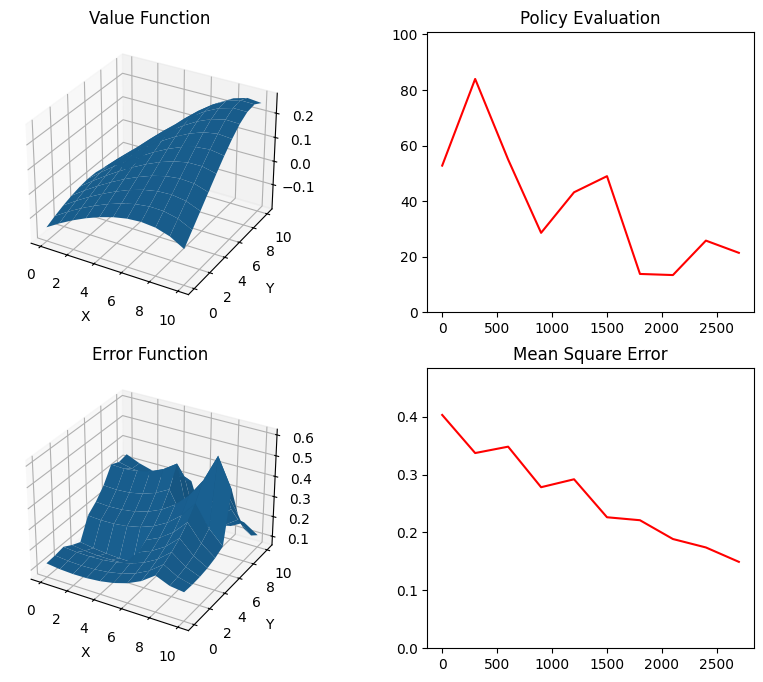

V V V V V   V V V V V 
V V V V V   V V V V V 
V V V X V > V V V V V 
V V V V V   V V V V V 
> > V V V   V V V V V 
    >           V     
> > > > V   V V V V V 
> > > > V   > V V V V 
> > > > > > > > V V V 
> > > > ^   O > > V < 
> > > > ^   > > > ^ < 


=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=
DG Test on Episode: 3000
Average: 17.4
Goal: (0, 10)
Mean Square Error = 0.2961740584996278



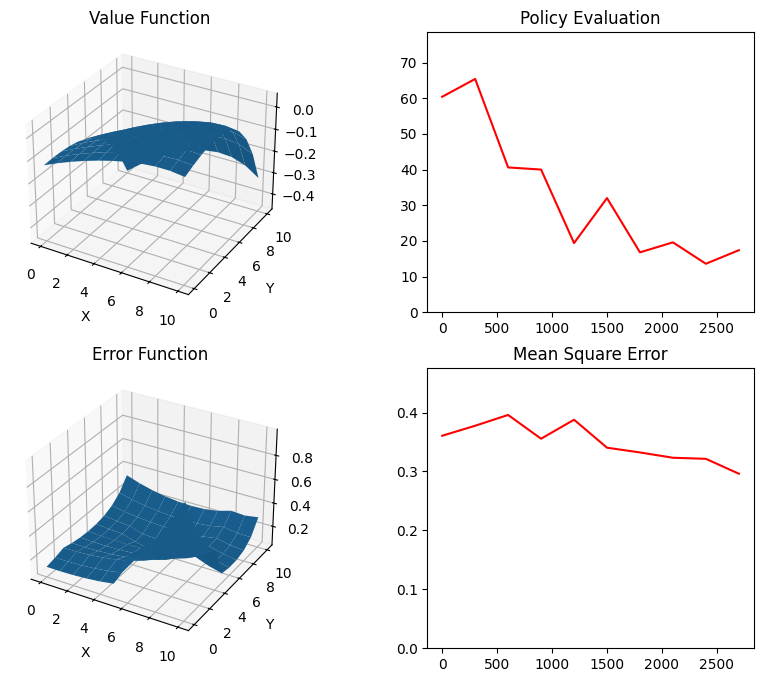

V V V V V   V < < < < 
V V V V V   V < < X < 
V V V V V < V < < < < 
V V V V V   V < < < < 
V V V V V   V < < < < 
    V           <     
V V V V V   V < < < < 
> > V V V   V < < < < 
> > > V V < < < < < < 
> > > > V   V < < < < 
O > > > ^   ^ < < < < 


_____________________________________________________________________________________________________
Train Policy Episode: 3000
Average: 25.2
Goal: (10, 10)
Mean Square Error = 0.16082600135792768



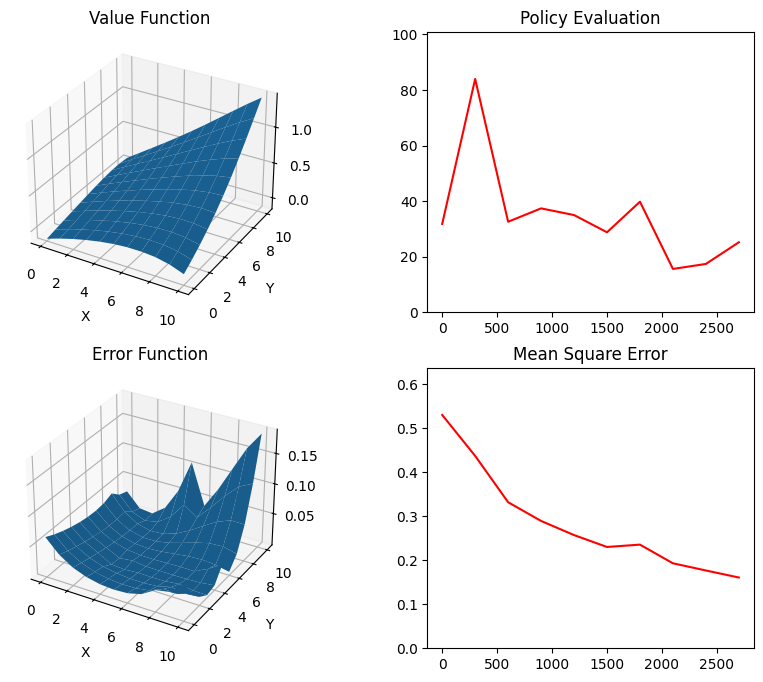

V V V V V   V V V V V 
V V V V V   V V V V V 
V V V V V > V V V V V 
V V V V X   V V V V V 
> > > > V   V V V V V 
    >           V     
> > > > V   > > V V V 
> > > > V   > > > V V 
> > > > > > > > > > V 
> > > > V   > > > > V 
> > > > ^   > > > > O 


=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=
DG Test on Episode: 3000
Average: 25.6
Goal: (0, 10)
Mean Square Error = 0.29799881064395434



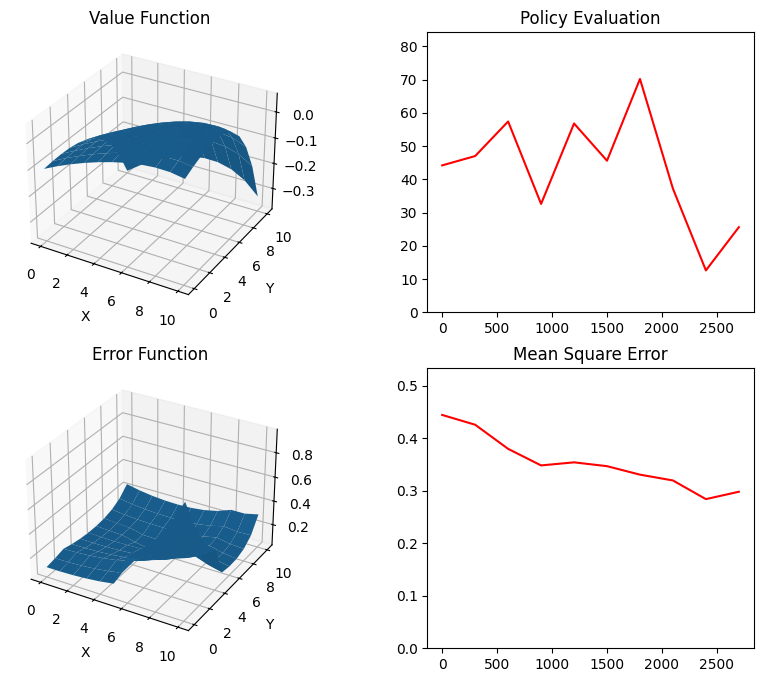

V V V V V   V V < < < 
V V V V V   V < < < < 
V V V V V < V < < < < 
V V V V V   V < < < < 
V V V V V   V < < < X 
    V           <     
> V V V V   V < < < < 
> > V V V   V < < < < 
> > > V V < < < < < < 
> > > > <   ^ < < < < 
O > > ^ ^   ^ < < < < 


_____________________________________________________________________________________________________
Train Policy Episode: 3000
Average: 22.4
Goal: (9, 10)
Mean Square Error = 0.15986927143667745



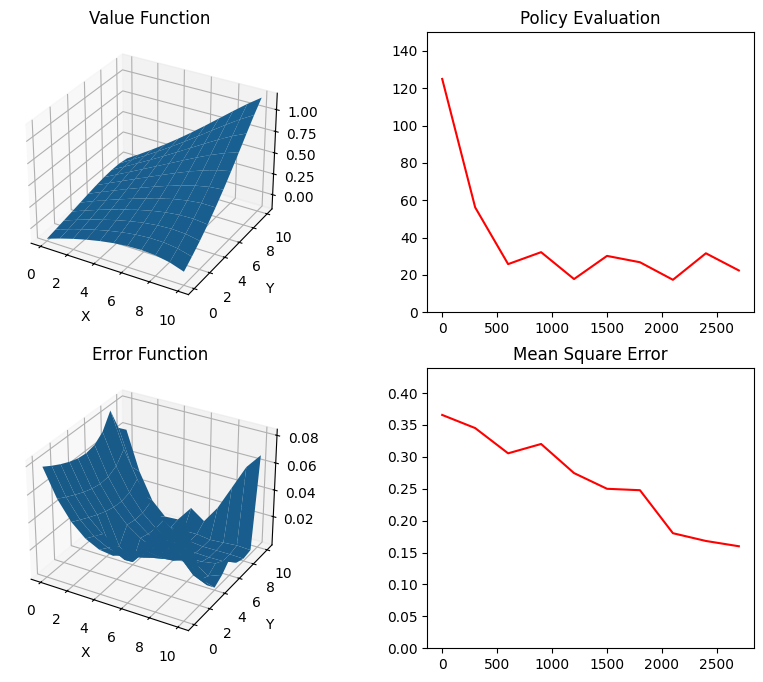

V V V V V   V V V V V 
V V V V V   V V V V V 
V V V V V > V V V V V 
V V V V V   V V V V V 
X > > > V   V V V V V 
    >           V     
> > > > V   > V V V V 
> > > > V   > > V V V 
> > > > > > > > > V V 
> > > > V   > > > > V 
> > > > ^   > > > O ^ 


=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=
DG Test on Episode: 3000
Average: 30.4
Goal: (0, 6)
Mean Square Error = 0.29563502191569435



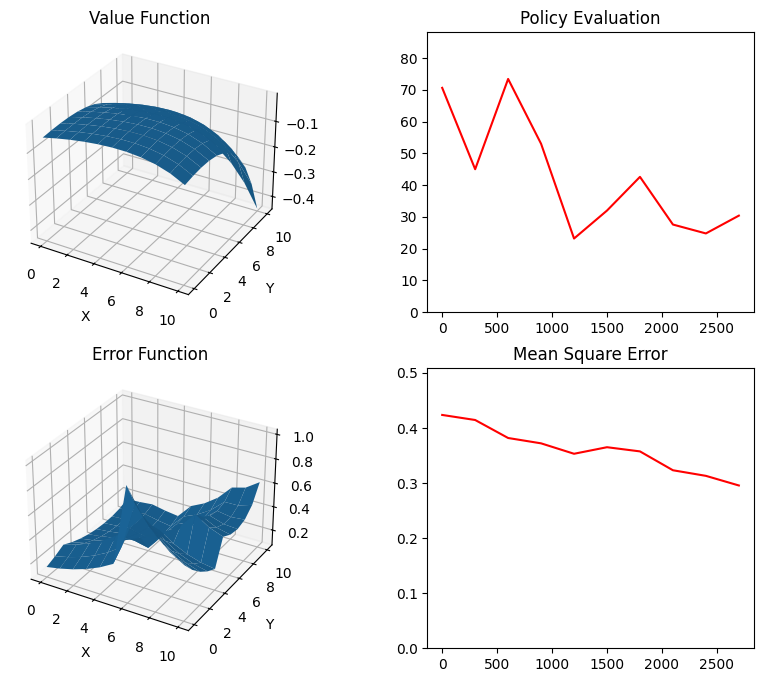

V V V V V   V < < < < 
V V V V V   V < < < < 
V V V V V < < < < < < 
V V V V V   V < < X < 
> V V V V   V < < < < 
    >           <     
O > > ^ <   ^ < < < < 
> ^ ^ ^ ^   ^ < < < < 
^ ^ ^ ^ ^ < < < < < < 
^ ^ ^ ^ ^   ^ < < < < 
^ ^ ^ ^ ^   ^ ^ < < < 


_____________________________________________________________________________________________________
Train Policy Episode: 3000
Average: 26.6
Goal: (7, 10)
Mean Square Error = 0.1398820411900368



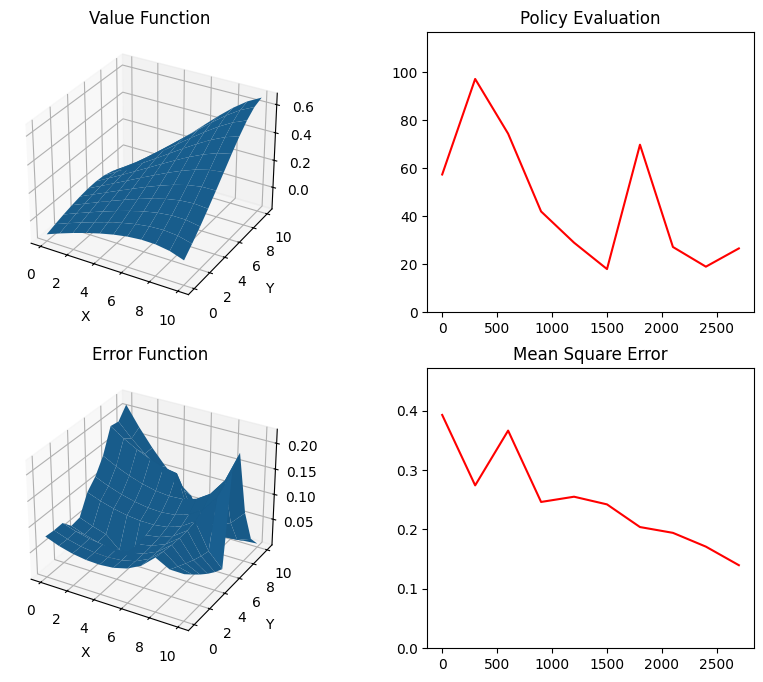

V V V V V   V V V V V 
V V V V X   V V V V V 
V V V V V > V V V V V 
V V V V V   V V V V V 
> > V V V   V V V V V 
    >           V     
> > > > V   V V V V V 
> > > > V   V V V V V 
> > > > > > > > V V V 
> > > > V   > > > V V 
> > > > ^   > O > > < 


=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=
DG Test on Episode: 3000
Average: 14.4
Goal: (4, 9)
Mean Square Error = 0.28467494256815096



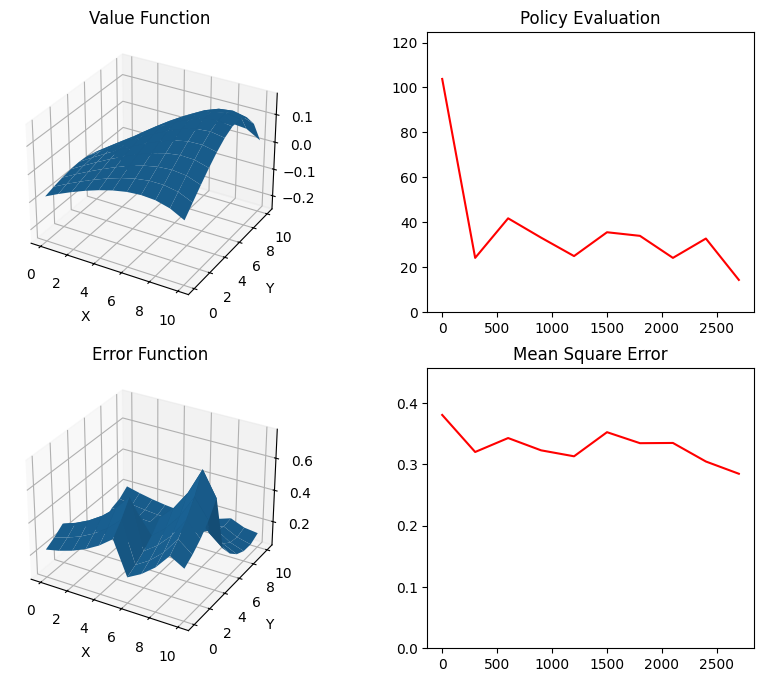

V V V V V   V V V < < 
V V V V V   V V V < < 
V V V V V < V V V < < 
V V V V V   V V V V < 
> V V V V   V X V V < 
    >           V     
> > > > V   V V V < < 
> > > > V   V V V < < 
> > > > > > V V < < < 
> > > > O   > < < < < 
> > > > ^   ^ ^ < < < 


_____________________________________________________________________________________________________
Train Policy Episode: 3000
Average: 11.4
Goal: (6, 7)
Mean Square Error = 0.1564109274827945



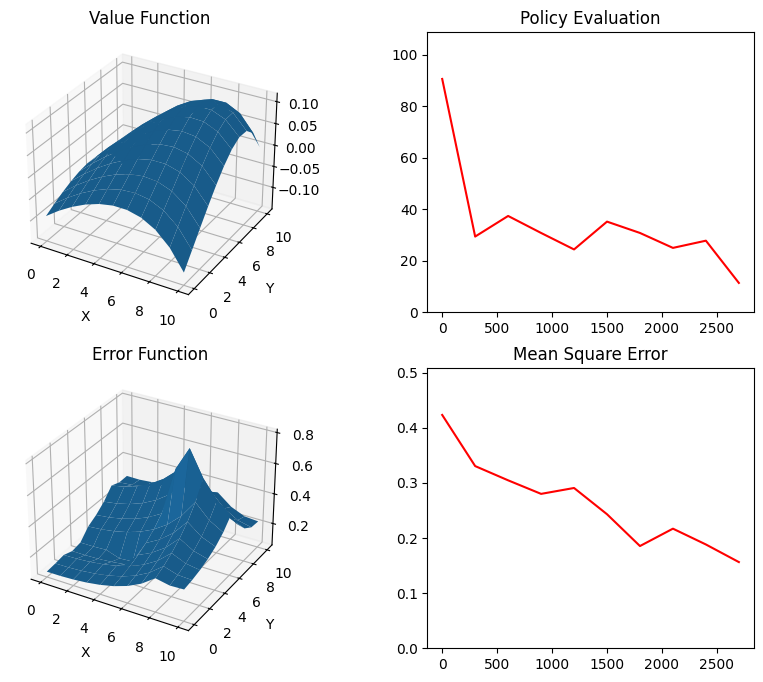

V V V V V   V V V V < 
V V V V V   V V V V < 
V V X V V > V V V V < 
> > > V V   V V V V < 
> > > > V   V V V V < 
    >           V     
> > > > V   > V V < < 
> > > > ^   O > V < < 
> > > > > > > > ^ < < 
^ > > > ^   ^ ^ ^ < < 
^ ^ ^ ^ ^   ^ ^ ^ ^ < 


=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=---=
DG Test on Episode: 3000
Average: 17.2
Goal: (1, 6)
Mean Square Error = 0.2879956017555774



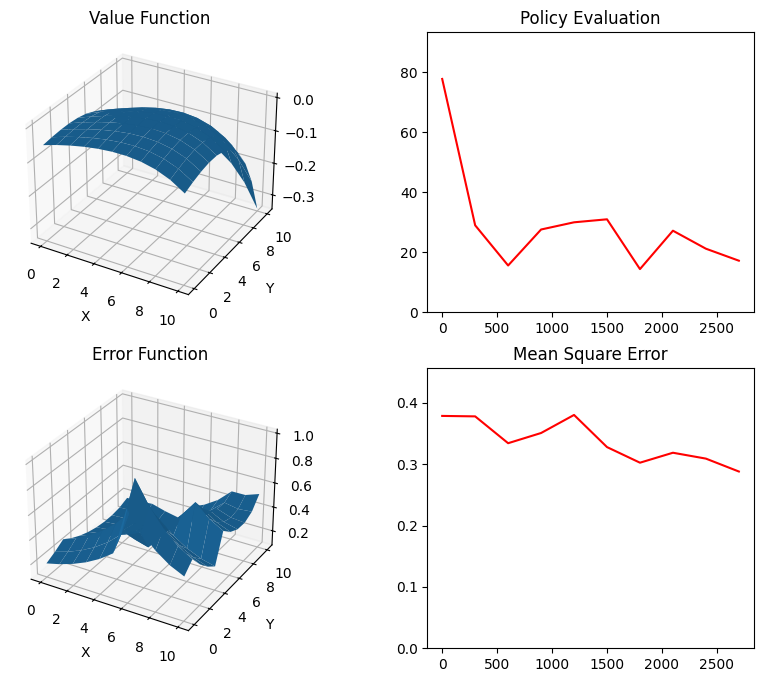

V V V V V   V < < < < 
V V V V V   V < < < < 
V V V V V < X < < < < 
V V V V V   V < < < < 
> > V V V   V < < < < 
    >           <     
> O > > <   ^ < < < < 
> > > ^ ^   ^ < < < < 
^ ^ ^ ^ ^ < < < < < < 
^ ^ ^ ^ ^   ^ < < < < 
^ ^ ^ ^ ^   ^ ^ < < < 


_____________________________________________________________________________________________________


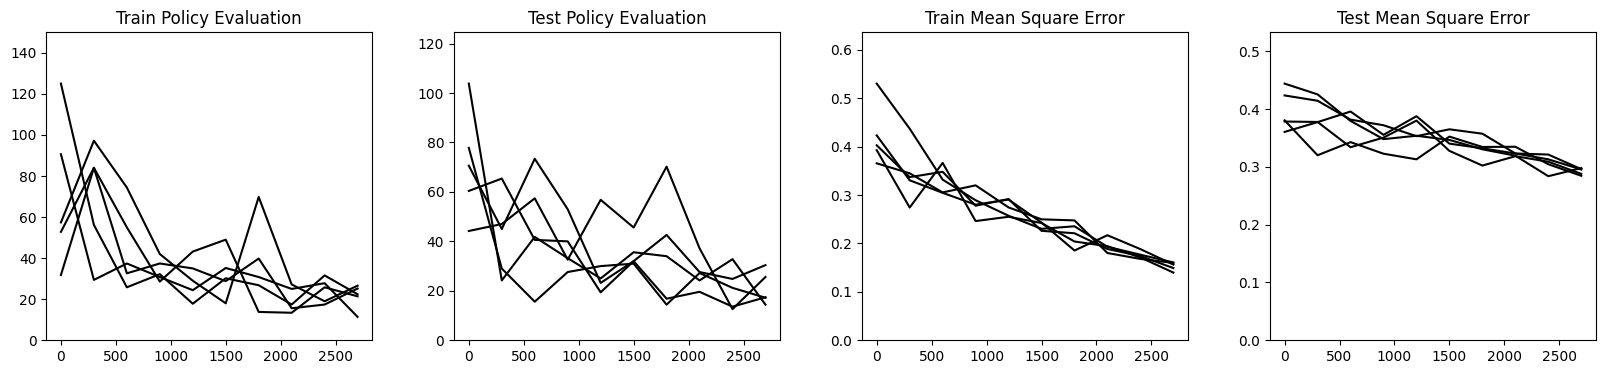

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.mplot3d import Axes3D
from scipy.sparse.linalg import cg
from google.colab import auth
import gspread
from google.auth import default
import random
import itertools
import math
auth.authenticate_user()
creds, _ = default()

temp_epnum = 3000
ROOM_SIZE = 5  #Odd
DEGREE = 4
EPISODES = 10000
SHOW_EPISODE = temp_epnum  #Multiple of SAVE_EPISODE
SAVE_EPISODE = temp_epnum/10
START_TD = 0
DISCOUNT = .9
SIZE = ROOM_SIZE*2+1
NUM_TEST = 5
BATCH_SIZE = ROOM_SIZE
SHOW_LAST_PROP = 1


def main(update_rule,STEP_SIZE_0,STEP_SIZE_1,FD_EPSILON,OUTER_STEP_SIZE):
    epsilon = 1
    step_size = STEP_SIZE_0
    weights = np.full((DEGREE+1,)*6, 0.0)
    train_avg,test_avg,train_MSE,test_MSE = [],[],[],[]

    for current in range(temp_epnum):
        pos_goal = combined_pos_goal(update_rule)
        td_adapted = weights.copy()
        gradients = [[],[],[],[]]
        outer_step_size = OUTER_STEP_SIZE/(1+EPISODES/100)
        save_features = ()

        for index,(pos,goal) in enumerate(pos_goal):
            dist = np.subtract(goal,pos)

            a = pick_action(pos,goal,epsilon,weights)
            action = (round(math.cos(a)),round(math.sin(a)))
            new_pos = find_new(action,pos)
            new_dist = np.subtract(goal,new_pos)

            features = calc_features(pos,goal,dist)
            next_features = calc_features(new_pos,goal,new_dist)
            if index>0:
                save_features[0].append(features)
                save_features[1].append(next_features)
            else:
                save_features = ([features],[next_features])

            reward = find_reward(pos,new_pos,goal)
            old_value = np.sum(np.multiply(weights,features))
            new_value = np.sum(np.multiply(weights,next_features))

            weights,td_adapted,gradients = inner_update(step_size,reward,new_value,old_value,features,update_rule,td_adapted,weights,current,index,gradients)

        weights = outer_update(weights,outer_step_size,td_adapted,update_rule,current,pos_goal,gradients,save_features)

        if((current+1)%SAVE_EPISODE==0):
            train_avg,train_MSE = calc_average(epsilon,weights,train_avg,train_MSE,current,test=False)
            test_avg,test_MSE = calc_average(epsilon,weights,test_avg,test_MSE,current)

        epsilon = epsilon - epsilon/(EPISODES//2-1)
        step_size = STEP_SIZE_0/(1+((STEP_SIZE_0-STEP_SIZE_1)/(STEP_SIZE_1*EPISODES))*current)

    start_index = int(max(np.floor(temp_epnum/SAVE_EPISODE*(1-SHOW_LAST_PROP))-1,0))
    return train_avg[start_index:],test_avg[start_index:],train_MSE[start_index:],test_MSE[start_index:],start_index


def calc_average(epsilon,weights,store_avg,store_MSE,current,test=True):
    pos_0 = (0,0)
    dist = (0,0)
    count,average = 0,0

    for i in range(NUM_TEST):
        pos,goal = (0,0),(0,0)
        if(test):
            pos = (np.random.randint(ROOM_SIZE+1,SIZE),np.random.randint(0,ROOM_SIZE))
            goal = (np.random.randint(0,ROOM_SIZE),np.random.randint(ROOM_SIZE+1,SIZE))
        else:
            pos = (np.random.randint(0,ROOM_SIZE),np.random.randint(0,ROOM_SIZE))
            goal = (np.random.randint(ROOM_SIZE+1,SIZE),np.random.randint(ROOM_SIZE+1,SIZE))
        pos_0 = pos
        dist = np.subtract(goal,pos)
        while((dist[0]!=0)and(dist[1]!=0)):
            a = pick_action(pos,goal,epsilon,weights)
            action = (round(math.cos(a)),round(math.sin(a)))
            new_pos = find_new(action,pos)
            new_dist = np.subtract(goal,new_pos)
            pos = new_pos
            dist = new_dist
            count += 1
        average = (average*i+count)/(i+1)
        count = 0
    store_avg.append(average)
    store_MSE = show_current(weights,goal,current,average,store_avg,store_MSE,pos_0,test=test)
    return store_avg,store_MSE

def show_current(weights,goal,current,average,store_avg,store_MSE,pos_0,test=True):
    MSE = find_MSE(test,weights)
    store_MSE.append(MSE)
    if((current+1)%SHOW_EPISODE==0):
        print(('DG Test on Episode: 'if test else 'Train Policy Episode: ')+str(current+1)+'\nAverage: '+str(average)+'\nGoal: '+str(goal)+'\nMean Square Error = '+str(MSE),end='\n\n')
        x,y = np.meshgrid(np.arange(SIZE),np.arange(SIZE))
        z1 = np.array([[find_value((i, j), goal, np.subtract(goal, (i, j)), weights) for j in range(SIZE)] for i in range(SIZE)])
        fig = plt.figure(figsize=(12,8))
        gs = GridSpec(2, 2, width_ratios=[2,1],height_ratios=[1,1])
        ax1 = fig.add_subplot(gs[0,0], projection="3d")
        ax1.plot_surface(x,y,z1)
        ax1.set(title='Value Function',xlabel='X',ylabel='Y')
        ax1.view_init(elev=30, azim=-60)
        ax2 = fig.add_subplot(gs[0,1])
        ax2.plot(SAVE_EPISODE*np.arange(len(store_avg)),np.array(store_avg),color='red')
        ax2.set(title='Policy Evaluation',ylim=[0,1.2*max(store_avg)])
        #plt.xlim([0,EPISODES//SHOW_EPISODE])
        ax3 = fig.add_subplot(gs[1,0],projection='3d')
        z2 = np.array([[(find_value((i,j),goal,np.subtract(goal,(i,j)),weights)-optimal_value((i, j), goal, test=test))**2 for j in range(SIZE)] for i in range(SIZE)])
        #z2 = np.array([[optimal_value((i, j), goal) for j in range(SIZE)] for i in range(SIZE)])
        ax3.set(title='Error Function',xlabel='X',ylabel='Y')
        ax3.view_init(elev=30, azim=-60)
        ax3.plot_surface(x,y,z2)
        ax4 = fig.add_subplot(gs[1,1])
        ax4.plot(SAVE_EPISODE*np.arange(len(store_MSE)),np.array(store_MSE),color='red')
        ax4.set(title='Mean Square Error',ylim=[0,1.2*max(store_MSE)])
        plt.subplots_adjust(wspace=-.1)
        plt.show()
        print_policy(weights,goal,pos_0)
        print('_'*101 if test else '=---'*25 +'=',end='\n')
    return store_MSE

def find_MSE(test,weights):
    posx,posy = np.indices((SIZE-1,SIZE-1))
    posx = [[posx[i][j] if posx[i][j]<ROOM_SIZE else posx[i][j]+1 for j in range(len(posx[i]))] for i in range(len(posx))]
    posy = [[posy[i][j] if posy[i][j]<ROOM_SIZE else posy[i][j]+1 for j in range(len(posy[i]))] for i in range(len(posy))]
    posx,posy = list(np.ndarray.flatten(np.array(posx))),list(np.ndarray.flatten(np.array(posy)))
    posx.extend([ROOM_SIZE,SIZE-(ROOM_SIZE-1)/2-1,ROOM_SIZE,(ROOM_SIZE-1)/2])
    posy.extend([(ROOM_SIZE-1)/2,ROOM_SIZE,SIZE-(ROOM_SIZE-1)/2-1,ROOM_SIZE])
    goalx,goaly = np.indices((ROOM_SIZE,ROOM_SIZE))
    goaly = goaly + ROOM_SIZE+1
    if(not test):
        goalx = goalx + ROOM_SIZE+1
    goalx,goaly = list(np.ndarray.flatten(np.array(goalx))),list(np.ndarray.flatten(np.array(goaly)))
    all_states = np.array([[(posx[i],posy[i],goalx[j],goaly[j],goalx[j]-posx[i],goaly[j]-posy[i]) for i in range(len(posx))] for j in range(len(goalx))],dtype=object)
    all_states = list(all_states.reshape(int(np.prod(all_states.shape)/6),6))
    all_states = random.sample(all_states,int(len(all_states)/SIZE))
    return sum([(find_value((all_states[i][0],all_states[i][1]),(all_states[i][2],all_states[i][3]),(all_states[i][4],all_states[i][5]),weights)- \
                optimal_value((all_states[i][0],all_states[i][1]),(all_states[i][2],all_states[i][3]),test=test))**2 for i in range(len(all_states))])/len(all_states)

def combined_pos_goal(update_rule):
    x1 = [[np.random.randint([0,ROOM_SIZE+1,0,ROOM_SIZE+1][i],[ROOM_SIZE,SIZE,ROOM_SIZE,SIZE][i]) for _ in range(BATCH_SIZE)] for i in range(4)]
    y1 = [[np.random.randint([0,0,ROOM_SIZE+1,ROOM_SIZE+1][i],[ROOM_SIZE,ROOM_SIZE,SIZE,SIZE][i]) for _ in range(BATCH_SIZE)] for i in range(4)]
    g1 = [[np.random.randint([ROOM_SIZE+1,ROOM_SIZE+1,ROOM_SIZE+1,ROOM_SIZE+1][i],[SIZE,SIZE,SIZE,SIZE][i]) for _ in range(BATCH_SIZE)] for i in range(4)]
    g2 = [[np.random.randint([ROOM_SIZE+1,ROOM_SIZE+1,ROOM_SIZE+1,ROOM_SIZE+1][i],[SIZE,SIZE,SIZE,SIZE][i]) for _ in range(BATCH_SIZE)] for i in range(4)]
#    if update_rule=='IDGM':
#        pos_combined = [zip(x1[i],y1[i]) for i in range(4)]
#        goal_combined = [zip(g1[i],g2[i]) for i in range(4)]
#    else:
    pos_combined = [(a, b) for c1, c2 in zip(x1, y1) for a, b in zip(c1, c2)]
    goal_combined = [(a, b) for c1, c2 in zip(g1, g2) for a, b in zip(c1, c2)]
    #print(list(zip(pos_combined,goal_combined)))
    return list(zip(pos_combined,goal_combined))

def inner_update(step_size,reward,new_value,old_value,features,update_rule,td_adapted,weights,current,index,gradient):
    td_error = step_size*(reward+DISCOUNT*new_value-old_value)*features
    if(update_rule=='td(0)' or current<=START_TD):
        weights = np.add(weights,td_error)
    if(update_rule=='Fish' and current>START_TD):
        td_adapted -= td_error
    if(update_rule=='IDGM' and current>START_TD):
        td_error /= step_size
        gradient[index//BATCH_SIZE].append(td_error)
    return weights,td_adapted,gradient

def outer_update(weights,outer_step_size,td_adapted,update_rule,current,pos_goal,gradient,save_features):
    if(update_rule=='Fish' and current>START_TD):
        weights = np.add(weights,outer_step_size*np.subtract(td_adapted,weights))
    if(update_rule=='IDGM' and current>START_TD):
        avg_g = np.mean(np.mean(gradient,axis=0),axis=0)
        domain_avgs = np.mean(gradient,axis=1)
        GIP,hessian = 0,compute_hessian(gradient,save_features,avg_g)
        for gi,gj in itertools.combinations(domain_avgs,2):
            GIP += np.dot(np.ndarray.flatten(gi),np.ndarray.flatten(gj))
        GIP /= 6
        weights -= outer_step_size*(np.subtract(avg_g,DISCOUNT*GIP*hessian))
    return weights

def compute_hessian(gradient, save_features, avg_g):
    flat_avg_g = np.ndarray.flatten(avg_g)
    H = np.zeros_like(flat_avg_g)
    for i in range(len(flat_avg_g)):
        FD_plus = flat_avg_g.copy()
        FD_minus = flat_avg_g.copy()
        FD_plus[i] += FD_EPSILON
        FD_minus[i] -= FD_EPSILON
        H[i] = (FD_plus[i] - FD_minus[i]) / (2 * FD_EPSILON)
    return H.reshape((DEGREE+1,)*6)

def calc_features(pos,goal,dist):
    indices = np.indices((DEGREE+1,)*6)
    start_x, start_y, end_x, end_y, x_dist, y_dist = [indices[i].flatten() for i in range(6)]
    temp = (
        ((pos[0]/SIZE)**start_x)*((pos[1]/SIZE)**start_y)*
        ((goal[0]/SIZE)**end_x)*((goal[1]/SIZE)**end_y)*
        ((dist[0]/SIZE)**x_dist)*((dist[1]/SIZE)**y_dist)
    )
    temp = temp.reshape((DEGREE+1,)*6)
    return(temp)

def pick_action(pos,goal,epsilon,weights):
    if(np.random.random()<epsilon):
        return(np.random.choice([0,np.pi/2,np.pi,3*np.pi/2]))
    else:
        return((np.pi/2)*arg_max(pos,goal,weights))

def arg_max(pos,goal,weights):
    values = np.zeros(4)
    for i in range(4):
        new_pos = find_new((round(math.cos(np.pi/2*i)),round(math.sin(np.pi/2*i))),pos)
        if(new_pos[0]!=pos[0]or new_pos[1]!=pos[1]):
            values[i] = find_value(new_pos,goal,np.subtract(goal,new_pos),weights)
        else:
            values[i] = -math.inf
    return(np.argmax(values))

def find_value(pos,goal,dist,weights):
    return np.sum(np.multiply(calc_features(pos,goal,dist),weights))

def min_dist(pos,goal,index=-1):
    if(index==-1):
        return min(np.sum([abs(np.subtract(pos,goal)[i]) for i in [0,1]]),np.sum([abs(np.subtract(pos,(goal[1],goal[0]))[i]) for i in [0,1]]))
    return [np.sum([abs(np.subtract(pos,((ROOM_SIZE-1)/2,ROOM_SIZE-1))[i]) for i in [0,1]]) + np.sum([abs(np.subtract(goal,(SIZE-ROOM_SIZE,SIZE-1-(ROOM_SIZE-1)/2))[i]) for i in [0,1]]), \
            np.sum([abs(np.subtract(pos,(ROOM_SIZE-1,(ROOM_SIZE-1)/2))[i]) for i in [0,1]]) + np.sum([abs(np.subtract(goal,(SIZE-1-(ROOM_SIZE-1)/2,SIZE-ROOM_SIZE))[i]) for i in [0,1]])][index]

def optimal_value(pos,goal,first=True,test=False):
    if(pos==goal):
        return find_reward(pos,pos,goal)
    if(not first):
        return find_reward((-1,-1),pos,goal) + DISCOUNT*optimal_value((pos[0]-1,pos[1]),goal,first=False,test=test)
    d = 0
    if(test):
        pos = (SIZE-pos[0]-1,pos[1])
        goal = (SIZE-goal[0]-1,goal[1])
    if(pos[0]<ROOM_SIZE and pos[1]<ROOM_SIZE):
        i = np.argmin([np.sum([abs(np.subtract(pos,((ROOM_SIZE-1)/2,ROOM_SIZE-1))[i]) for i in [0,1]]) + np.sum([abs(np.subtract(goal,(SIZE-ROOM_SIZE,SIZE-1-(ROOM_SIZE-1)/2))[i]) for i in [0,1]]), \
            np.sum([abs(np.subtract(pos,(ROOM_SIZE-1,(ROOM_SIZE-1)/2))[i]) for i in [0,1]]) + np.sum([abs(np.subtract(goal,(SIZE-1-(ROOM_SIZE-1)/2,SIZE-ROOM_SIZE))[i]) for i in [0,1]])])
        d = min_dist(pos,goal,index=i) + ROOM_SIZE+3
    elif(pos[0]>ROOM_SIZE and pos[1]>ROOM_SIZE):
        d = np.sum([abs(np.subtract(pos,goal)[i]) for i in [0,1]])
    else:
        d = min_dist(pos,(SIZE-1-(ROOM_SIZE-1)/2,SIZE-ROOM_SIZE)) + min_dist(goal,(SIZE-1-(ROOM_SIZE-1)/2,SIZE-ROOM_SIZE))
    return (find_reward((d-1,0),(d,0),(0,0)) + DISCOUNT*optimal_value((d-1,0),(0,0),first=False,test=test))

def find_new(action,pos):
    new_pos = [min(SIZE-1,max(0,action[i]+pos[i])) for i in range(2)]
    for i in range(2):
        if(new_pos[0]==ROOM_SIZE and (new_pos[1-i]!=ROOM_SIZE//2 and new_pos[1-i]!=2*ROOM_SIZE-ROOM_SIZE//2)):
            new_pos[i] = pos[i]
    return tuple(new_pos)

def find_reward(pos,new_pos,goal):
    if(new_pos==goal):
        return 1
    elif(pos==new_pos):
        return(-1/ROOM_SIZE)
    else:
        return 0
        return(-np.sum([abs(np.subtract(new_pos,goal)[i]) for i in [0,1]])/ROOM_SIZE)

def print_policy(weights,goal,pos):
    sym = {0: ">", 1: "V", 2: "<", 3: "^"}
    for y in range(SIZE):
        for x in range(SIZE):
            if((x,y)==goal):
                print('O',end=' ')
            elif((x,y)==pos):
                print('X',end=' ')
            elif((x==ROOM_SIZE and (y not in {ROOM_SIZE//2,2*ROOM_SIZE-ROOM_SIZE//2}))or \
                 (y==ROOM_SIZE and (x not in {ROOM_SIZE//2,2*ROOM_SIZE-ROOM_SIZE//2}))):
                print(' ',end=' ')
            else:
                print(sym[arg_max((x,y),goal,weights)],end=' ')
        print()
    print('\n')

np.set_printoptions(threshold=np.inf)
#update_rule,STEP_SIZE_0,STEP_SIZE_1,DISCOUNT,FD_EPSILON,OUTER_STEP_SIZE


train_avg,test_avg,train_MSE,test_MSE = [],[],[],[]
start_index = 0
for i in range(5):
    a,b,c,d,start_index = main('td(0)',1e-2,5e-5,1e-4,5e-3)
    train_avg.append(a),test_avg.append(b),train_MSE.append(c),test_MSE.append(d)
train_avg = np.array(train_avg)
test_avg = np.array(test_avg)
train_MSE = np.array(train_MSE)
test_MSE = np.array(test_MSE)
fig = plt.figure(figsize=(20,4))
gs = GridSpec(1, 4, width_ratios=[1,1,1,1])
ax1 = fig.add_subplot(gs[0])
for i in range(len(train_avg)):
    ax1.plot(SAVE_EPISODE*(np.arange(len(train_avg[i]))+start_index),np.array(train_avg[i]),color='black')
ax1.set(title='Train Policy Evaluation',ylim=[0,1.2*train_avg.max()])
ax2 = fig.add_subplot(gs[1])
for i in range(len(test_avg)):
    ax2.plot(SAVE_EPISODE*(np.arange(len(test_avg[i]))+start_index),np.array(test_avg[i]),color='black')
ax2.set(title='Test Policy Evaluation',ylim=[0,1.2*test_avg.max()])
ax3 = fig.add_subplot(gs[2])
for i in range(len(train_MSE)):
    ax3.plot(SAVE_EPISODE*(np.arange(len(train_MSE[i]))+start_index),np.array(train_MSE[i]),color='black')
ax3.set(title='Train Mean Square Error',ylim=[0,1.2*train_MSE.max()])
ax4 = fig.add_subplot(gs[3])
for i in range(len(test_MSE)):
    ax4.plot(SAVE_EPISODE*(np.arange(len(test_MSE[i]))+start_index),np.array(test_MSE[i]),color='black')
ax4.set(title='Test Mean Square Error',ylim=[0,1.2*test_MSE.max()])
plt.subplots_adjust(wspace=.25)
plt.show()